# **Model Evaluation under Temperature Variations**


In [1]:
import os
import pandas as pd
import json
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from collections import defaultdict
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import scipy.stats as st
import matplotlib.cm as cm
import matplotlib.colorbar as colorbar
from statsmodels.stats.contingency_tables import cochrans_q, mcnemar, Table
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
import plotly.graph_objects as go


import itertools

In [2]:
# ESAP questions with images
q_w_images = [3, 4, 6, 32, 35, 54, 68, 88]

cases = np.delete(np.arange(100), [0] + q_w_images) # valid questions
n_cases = cases.size

# Available options
options = ['A', 'B', 'C', 'D', 'E']
# even for the experiments without letter, manual annotator saved the option using letter.

path_to_results = "./../results"

model_file_name_dict = {'huatuo-o1': 'HuatuoGPT-o1',
                        'diabetica-o1': 'Diabetica-o1',
                        'diabetica-7B': 'Diabetica-7B',
                        'meditron3-8B': 'Meditron3-8B'}

In [3]:
def evaluate_response_distrib(filepath):
    """ 
    Given the excel file, this function parses and standardize the file entries.
    Returns a counter in the form of a dictionary.
    """
    df_ = pd.read_excel(filepath, header=None, index_col=0)
    
    # everything capital
    df_ = df_.map(lambda x: x.upper() if isinstance(x, str) else x) 
    
    # remove NaN values - this remove extra-columns
    df_ = df_.dropna(axis=1, how='all') 
    if not np.array_equal(df_.index, cases): # we keep all 91 cases
        raise ValueError("We are removing a valid case by mistake! Check Excel file")

    # unique annotations
    # print(df_.values)
    print(np.unique(df_.values))
    unique_elements = np.unique(df_.values) 

    # multiple options selected
    # are indicated as option1-option2: there is a dash
    bm_multiple = ["-" in v_ for v_ in unique_elements] 
    
    bm_hall_none = [True if (v_ == "HALL" or v_ == 'NONE') # hallucination or no response
                    else False for v_ in unique_elements]
    
    bm_others = ~np.logical_or(bm_multiple, bm_hall_none) # correct answers / check (temporary)
    
    idx_multiple = np.where(bm_multiple)[0] # indexes
    idx_hall_none = np.where(bm_hall_none)[0]
        
    dct_counter = {}
    all_ = 0 # to make sure we did not miss any response (91 or multiple for 10 rep)

    # we are creating a new label for multi and hall/none
    if len(idx_multiple) > 0:
        count = 0
        for v_ in unique_elements[idx_multiple]:
            count += (df_.values == v_).sum()
        all_ = count
        dct_counter["MULTI"] = count
            
    if len(idx_hall_none) > 0:
        count = 0
        for v_ in unique_elements[idx_hall_none]:
            count += (df_.values == v_).sum()
        all_ += count
        dct_counter["HALL / NONE"] = count
       
    # we are using the old label for everything else
    for element in unique_elements[bm_others]:
        count = (df_.values == element).sum()
        dct_counter[element] = count
        all_ += count
            
    list_add = ["CHECK", "MULTI", "HALL / NONE", "A", "B", "C", "D", "E"]
    for el_ in list_add:
        if el_ not in dct_counter.keys():
            dct_counter[el_] = 0
    dct_counter["TOTAL"] = all_
        
    return dct_counter

In [4]:
model_paths_token = {'meditron3-8B-prompt1': 'meditron3-8B_promptID_001_output_4.xlsx',
                     'huatuo-o1-prompt1': 'huatuo-o1_promptID_001_output_9.xlsx',
                     'huatuo-o1-prompt2': 'huatuo-o1_promptID_002_output_11.xlsx',
                     'diabetica-o1-prompt1': 'diabetica-o1_promptID_001_output_2.xlsx',
                     'diabetica-o1-prompt2': 'diabetica-o1_promptID_002_output_3.xlsx',
                     'diabetica-7B-prompt1': 'diabetica-7B_promptID_001_output_3.xlsx',
                     'diabetica-7B-prompt2': 'diabetica-7B_promptID_002_output_4.xlsx',
                     'medfound7B-prompt1': 'medfound7B_promptID_001_output_2.xlsx',
                     'medfound7B-prompt2': 'medfound7B_promptID_002_output_3.xlsx',
                     'clinical-chatgpt-prompt1': 'clinical-chatgpt_promptID_001_output_2.xlsx',
                     'clinical-chatgpt-prompt2': 'clinical-chatgpt_promptID_002_output_3.xlsx',
                     'bloom-7b-prompt1': 'bloom-7B_promptID_001_output_0.xlsx',
                     'bloom-7b-prompt2': 'bloom-7B_promptID_002_output_1.xlsx',
                     'llama31-prompt1': 'llama31_promptID_001_output_6.xlsx',
                     'llama31-prompt2': 'llama31_promptID_002_output_7.xlsx',
                     'qwen2-7b-prompt1': 'qwen2-7b_promptID_001_output_0.xlsx',
                     'qwen2-7b-prompt2': 'qwen2-7b_promptID_002_output_1.xlsx',
                     'huatuo-o1-lms-prompt1': 'huatuo-o1-lms-prompt001.xlsx',
                     'gpt-oss-20b-prompt1': 'gpt-oss-20b-lms-prompt001.xlsx'
                    }

model_paths_no_token = {'huatuo-o1': 'huatuo-o1_promptID_001_output_47.xlsx',
                        'diabetica-o1': 'diabetica-o1_promptID_001_output_40.xlsx',
                        'diabetica-7B': 'diabetica-7B_promptID_001_output_47.xlsx',
                        'meditron3-8B': 'meditron3-8B_promptID_001_output_39.xlsx',
                        'clinical-chatgpt': 'clinical-chatgpt_promptID_001_output_4.xlsx',
                        'medfound7B': 'medfound7B_promptID_001_output_4.xlsx',
                        'bloom-7b': 'bloom-7b_promptID_001_output_2.xlsx',
                        'llama31': 'llama31_promptID_001_output_8.xlsx',
                        'qwen2-7b': 'qwen2-7b_promptID_001_output_2.xlsx'
                       }

In [5]:
def counter_extensive_dfs(result_folder, dct_models, letter=True):
    """ 
    Used in experiment 1 to a) keep track of distribution of responses
    b) build dataframe with extensive results.
    
    Variables: 
    result_folder: str, folder containing model's output
    dct_models: str, excel file 
    letter: bool, if True, ESAP question, otherwise, letter removed from option
    
    Returns:
    df_counter: pd.DataFrame, distribution of models responses
    df_all: pd.DataFrame extensive (91 outputs)
    """
    list_df = []
    index = []
    counting_outputs = []

    for model_, file_ in dct_models.items():
        if letter:
            filepath = join(path_to_results, model_.split("-prompt")[0], file_)
        else: 
            filepath = join(path_to_results, "NO_LETTERS", file_)
            
        df_ = pd.read_excel(filepath, header=None, index_col=0)
        df_ = df_[1] # we keep first column, others are empty
        list_df.append(df_)
        
        dct_counter = evaluate_response_distrib(filepath)
        counting_outputs.append([dct_counter[k] for k in sorted(dct_counter.keys())])

    # this is for the counter
    columns_name = sorted(dct_counter.keys())
    
    list_model_name = [m_ if letter else f"{m_}_no_letter" for m_ in dct_models.keys()]

    df_counter = pd.DataFrame(data=counting_outputs, 
                              index=list_model_name,
                              columns=columns_name)

    # this is for the Df with 91 responses
    df_all = pd.concat(list_df, axis=1)
    df_all.columns = list_model_name
    
    return df_counter, df_all

In [6]:
df_counter_prompt_A_B, df_all = counter_extensive_dfs(path_to_results, model_paths_token)

['A' 'B' 'C' 'D' 'E' 'NONE']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'D' 'E' 'HALL']
['A' 'B' 'C' 'D' 'E']
['A' 'A-B' 'A-C' 'B' 'C' 'D' 'E' 'HALL' 'NONE']
['A' 'B' 'C' 'D' 'HALL' 'NONE']
['A' 'A-B-C-D-E' 'B' 'C' 'D' 'D-E' 'E' 'HALL' 'NONE']
['A' 'A-B' 'A-B-C-D-E' 'A-C' 'B' 'C' 'D' 'E' 'NONE']
['A' 'A-B' 'A-C' 'B' 'C' 'D' 'HALL' 'NONE']
['A' 'A-B' 'A-B-C' 'A-B-C-D' 'A-B-C-D-E' 'A-D' 'B' 'C' 'D' 'HALL' 'NONE']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'C-D' 'D' 'E']
['A' 'B' 'C' 'D' 'E']
['A' 'B' 'C' 'D' 'E' 'NONE']


In [7]:
df_counter_no_let, df_all_no_let = counter_extensive_dfs(path_to_results, model_paths_no_token, letter=False)

['A' 'B' 'C' 'C-D' 'D' 'E' 'NONE']
['A' 'A-B' 'B' 'C' 'C-D' 'D' 'E' 'HALL' 'NONE']
['A' 'A-B' 'B' 'B-C' 'C' 'C-D' 'C-E' 'D' 'E' 'HALL' 'NONE']
['A' 'A-B' 'B' 'B-D' 'C' 'D' 'E' 'HALL' 'NONE']
['A' 'A-E' 'B' 'C' 'D' 'E' 'HALL' 'NONE']
['A' 'A-B-C' 'A-B-C-D-E' 'A-E' 'B' 'C' 'D' 'E' 'HALL' 'NONE']
['A' 'A-B' 'B' 'B-C' 'C' 'D' 'E' 'E-NONE' 'HALL' 'NONE']
['A' 'B' 'C' 'D' 'E' 'NONE']
['A' 'A-B' 'B' 'C' 'D' 'E']


In [8]:
# concatenate all results from experiment 1
df_all = pd.concat([df_all, df_all_no_let], axis=1)

In [9]:
with open("./../inference/Ped-ESAP.json", "r") as f:
    content = json.load(f)
    
responses = []
labs = []
table = []
for k, v in content.items():
    if len(v['answer']) > 0:
        responses.append(v['answer'][0])
        labs.append(v["labs"]=='Yes')
        table.append(v["table"]=='Yes')
    else:
        responses.append(None)
        labs.append(None)
        table.append(None)
        
ground_truth = pd.DataFrame(data=np.array(responses[:-1]).reshape(-1,1), index=np.arange(1,100),
                           columns=["truth"])
ground_truth = ground_truth.drop(q_w_images)

meta_labs_table = np.hstack((np.array(labs).reshape(-1,1), np.array(table).reshape(-1,1)))
meta_labs_tab_df = pd.DataFrame(data=meta_labs_table[:-1, :], index=np.arange(1,100),
                    columns=["labs", "table"])
meta_labs_tab_df = meta_labs_tab_df.drop(q_w_images)

In [10]:
# run only once, otherwise we get multiple "truth" columns
df_all = pd.concat([df_all, ground_truth], axis=1)

In [11]:
# here we keep the value in entry if is one among A, B, C, D, or E
# we report as NaN otherwise
for col in df_all.columns[:-1]:
    df_all[col] = df_all[col].where(df_all[col].isin(options), np.nan)

In [12]:
bm_valid = ~df_all.isna()

In [13]:
accuracy_df = df_all[df_all.columns[:-1]].eq(df_all['truth'], axis=0)

accuracy_df.head()

,meditron3-8B-prompt1,huatuo-o1-prompt1,huatuo-o1-prompt2,diabetica-o1-prompt1,diabetica-o1-prompt2,diabetica-7B-prompt1,diabetica-7B-prompt2,medfound7B-prompt1,medfound7B-prompt2,clinical-chatgpt-prompt1,...,gpt-oss-20b-prompt1,huatuo-o1_no_letter,diabetica-o1_no_letter,diabetica-7B_no_letter,meditron3-8B_no_letter,clinical-chatgpt_no_letter,medfound7B_no_letter,bloom-7b_no_letter,llama31_no_letter,qwen2-7b_no_letter
1,True,True,True,True,True,False,False,False,False,True,...,True,True,False,False,True,False,False,False,False,False
2,True,False,True,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
5,False,True,False,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,True,False,False,False,...,True,True,False,True,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
accuracy_scores = accuracy_df.sum()

In [15]:
models_col = df_all.columns[:-1] # we exclude the truth column

In [16]:
results = pd.concat([accuracy_scores[models_col], bm_valid[models_col].sum()], axis=1)
results.columns = ['# correct', '# interpretable']

In [17]:
os.makedirs("tables", exist_ok=True)
os.makedirs("plots", exist_ok=True)


In [18]:
model_list = ['HuatuoGPT-o1-8B', 'Meditron3-8B', 'Llama3.1-8B Instruct', 'Diabetica-o1', 'Diabetica-7B', 'Qwen2-7B Instruct']
model_file = ['huatuo-o1', 'meditron3-8B', 'llama31', 'diabetica-o1', 'diabetica-7B', 'qwen2-7b']
temperature_list = [0.3, 0.6, 1.]
path_repetitions = f"{path_to_results}/REPETITIONS"

The following comparison matrix contains the number of times the LLMs select the correct option. 

``rep_df`` is a Excel with 91 rows (cases) and 10 columns (repetitions).

We repeat this across the three temperatures tested.

In [19]:
def max_frequency_string(arr, identify_majority=True):
    """ This code returns nan if there is no majorty selected (e.g., two options with same
    frequency). Otherwise, option and how many times it was selected. """
    # with identify mayority=True, we count how many times majority was selected
    # with identify_majority False, we do not care about majority, we just want the count of the max selection
    if not arr.size:
        return None, 0
    unique_elements, counts = np.unique(arr, return_counts=True)
    max_indexes = counts == np.max(counts)
    if np.sum(max_indexes) > 1:
        if identify_majority:
            return np.nan, np.nan # returns not a number if we do not have a majority
        else:
            return np.nan, np.max(counts)
    # elif unique_elements[np.argmax(counts)] not in options:
    #     return np.nan, np.nan # if max option is none
    else:
        return unique_elements[np.argmax(counts)], np.max(counts)

Counting outputs: There are some cases where models does not make a selection, we report these values as well.

In [20]:
# what is the accuracy for each run, model, temperature
bm_across_models_and_t = []
comparison_mat_all = []
most_sel_list_and_t = []
count_sel_list_and_t = []

for t_ in temperature_list:
    bm_across_models = []
    comparison_mat = []
    most_sel_list = []
    count_sel_list = []

    for m_ in model_file: 
        # for each model and temperature we load the excel and retrieve information
        rep_df = pd.read_excel(f"{path_repetitions}/T={t_}/{m_}/{m_}_promptID_001_repetitions.xlsx",
                               header=None, index_col=0)
        comparison = rep_df.eq(df_all['truth'], axis=0)
        
        most_sel = []
        count_sel = []
        for id_row, row in enumerate(rep_df.values):
            row = row[~pd.isna(row)]
            cat, count = max_frequency_string(row)
            most_sel.append(cat)
            count_sel.append(count)
        most_sel_list.append(np.array(most_sel))
        count_sel_list.append(np.array(count_sel))
        
        # how many times correct option selected across 10 runs
        comparison_mat.append(comparison.sum(axis=1).values) 
        
        # accuracy for each run
        bm_across_models.append(comparison.sum(axis=0).values) 
        
    most_sel_list_and_t.append(most_sel_list)
    count_sel_list_and_t.append(count_sel_list)
    comparison_mat_all.append(np.array(comparison_mat))
    bm_across_models_and_t.append(bm_across_models)
    
comparison_mat = np.array(comparison_mat_all)
most_sel_list_and_t = np.array(most_sel_list_and_t)
count_sel_list_and_t = np.array(count_sel_list_and_t)

indexes_questions = rep_df.index    

In [21]:
print(comparison_mat.shape) # accuracy (10/10 = 100%, 0/10 = 0%)
print(most_sel_list_and_t.shape) # majority vote
print(count_sel_list_and_t.shape) # frequency of majority vote

(3, 6, 91)
(3, 6, 91)
(3, 6, 91)


Saving the majority vote frequency:

In [22]:
unique_vals = np.unique(most_sel_list_and_t)
count_t_m = np.zeros((len(temperature_list), len(model_list), len(unique_vals)), dtype=int)
list_df = []
for id_t, t in enumerate(temperature_list):
    for id_m, m in enumerate(model_list):
        for id_v, v_ in enumerate(unique_vals):
            count_t_m[id_t, id_m, id_v] = np.sum(most_sel_list_and_t[id_t, id_m] == v_)
    majority_vote_ = pd.DataFrame(index=model_list, columns=unique_vals, data=count_t_m[id_t])
    majority_vote_.to_latex(f"tables/majority_vote_T={t}.tex")

In [23]:
majority_vote_

,A,B,C,D,E,NONE,nan
HuatuoGPT-o1-8B,17,23,20,15,11,0,5
Meditron3-8B,3,4,0,2,2,72,8
Llama3.1-8B Instruct,7,20,18,20,19,0,7
Diabetica-o1,13,19,25,16,8,0,10
Diabetica-7B,14,19,26,15,11,0,6
Qwen2-7B Instruct,14,21,26,16,9,0,5


Below, dataframes one per temperature, containing number of correct responses across runs (row) and models (column):

In [24]:
# this is a list of dataframes, one per temperature
df_accuracy_runs_list = [pd.DataFrame(bm_models_, index=model_list, columns=np.arange(1,11)).T 
                         for bm_models_ in bm_across_models_and_t]

In [25]:
df_accuracy_runs_list[0]

,HuatuoGPT-o1-8B,Meditron3-8B,Llama3.1-8B Instruct,Diabetica-o1,Diabetica-7B,Qwen2-7B Instruct
1,32,27,33,33,27,21
2,38,32,30,29,29,25
3,28,29,32,31,27,27
4,32,31,33,29,26,28
5,32,25,31,29,28,28
6,30,26,35,29,24,27
7,34,35,33,27,32,23
8,37,33,32,29,27,22
9,32,27,33,28,30,32
10,35,24,32,31,21,29


In [26]:
# Report hallucination for each model

counting_outputs = []
index = []

for t_ in temperature_list:
    for m_ in model_file: 
        print(t_, m_)
        filepath = f"{path_repetitions}/T={t_}/{m_}/{m_}_promptID_001_repetitions.xlsx"
        dct_counter = evaluate_response_distrib(filepath)
        print("HERE")
        index.append(f"T={t_} m={m_}")
        counting_outputs.append([dct_counter[k] for k in sorted(dct_counter.keys())])
columns_name = sorted(dct_counter.keys())

df_counter = pd.DataFrame(data=counting_outputs, 
                          index=index,
                          columns=columns_name)
# df_counter.to_latex("tables/readability_experiment2_20-04-2026.tex")
df_counter

0.3 huatuo-o1
['A' 'B' 'B-E' 'B-E-A' 'C' 'D' 'E' 'HALL']
HERE
0.3 meditron3-8B
['A' 'B' 'B-C' 'C' 'D' 'E' 'HALL' 'NONE']
HERE
0.3 llama31
['A' 'B' 'B-E' 'C' 'D' 'E' 'HALL' 'NONE']
HERE
0.3 diabetica-o1
['A' 'B' 'C' 'D' 'E']
HERE
0.3 diabetica-7B
['A' 'B' 'B-E' 'C' 'C-D' 'D' 'E' 'NONE']
HERE
0.3 qwen2-7b
['A' 'A-B' 'A-D-E' 'A-E' 'B' 'B-C' 'B-E' 'C' 'D' 'E' 'HALL']
HERE
0.6 huatuo-o1
['A' 'B' 'C' 'D' 'E' 'HALL']
HERE
0.6 meditron3-8B
['A' 'B' 'C' 'D' 'E' 'HALL' 'NONE']
HERE
0.6 llama31
['A' 'B' 'B-E' 'C' 'D' 'E' 'NONE']
HERE
0.6 diabetica-o1
['A' 'B' 'C' 'D' 'E' 'HALL' 'NONE']
HERE
0.6 diabetica-7B
['A' 'A-B' 'B' 'C' 'D' 'E' 'HALL' 'NONE']
HERE
0.6 qwen2-7b
['A' 'A-B' 'B' 'B-E' 'C' 'D' 'E' 'HALL' 'NONE']
HERE
1.0 huatuo-o1
['A' 'B' 'B-E' 'C' 'D' 'D-A' 'E' 'HALL' 'NONE']
HERE
1.0 meditron3-8B
['A' 'A-B' 'A-D' 'B' 'B-C' 'B-E' 'C' 'C-B' 'C-D' 'D' 'E' 'HALL' 'NONE']
HERE
1.0 llama31
['A' 'B' 'C' 'C-D' 'C-E' 'D' 'D-E' 'E' 'HALL' 'NONE']
HERE
1.0 diabetica-o1
['A' 'A-C' 'A-E' 'B' 'B-E' 'C' 'D'

,A,B,C,CHECK,D,E,HALL / NONE,MULTI,TOTAL
T=0.3 m=huatuo-o1,172,236,206,0,168,120,5,3,910
T=0.3 m=meditron3-8B,127,195,202,0,195,164,26,1,910
T=0.3 m=llama31,86,233,197,0,218,173,2,1,910
T=0.3 m=diabetica-o1,203,210,219,0,172,106,0,0,910
T=0.3 m=diabetica-7B,146,170,276,0,194,113,8,3,910
T=0.3 m=qwen2-7b,165,164,291,0,183,99,1,7,910
T=0.6 m=huatuo-o1,171,231,201,0,171,124,12,0,910
T=0.6 m=meditron3-8B,149,202,182,0,182,156,39,0,910
T=0.6 m=llama31,85,227,217,0,209,169,1,2,910
T=0.6 m=diabetica-o1,204,210,215,0,173,97,11,0,910


In [27]:
def plot_singular_responses(matrix_comparison, 
                            across_models=True, 
                            temp_id=1, 
                            model_id=None,
                            saveplot=False,
                            plotname=None):
    # temp 0 - 0.3, temp 1 - 0.6, temp 2 - 1.
    colors_palette = [
    "#b2182b",  # 0 - deep red
    "#d6604d",  # 1 - red-orange
    "#f4a582",  # 2 - orange
    "#fddbc7",  # 3 - light orange
    "#fee8c8",  # 4 - beige
    "#f7f7f7",  # 5 - white/neutral
    "#d1e5f0",  # 6 - very light blue
    "#92c5de",  # 7 - light blue
    "#4393c3",  # 8 - medium blue
    "#2166ac",  # 9 - dark blue
    "#053061",  # 10 - deepest blue
    ]
    
    fig, ax = plt.subplots(figsize=(30, 7))
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.tick_params(width=2)
    
    if across_models: 
        sorted_id_answer = np.argsort(comparison_mat[temp_id][0]) # temperature 0.6, sorted by Huatuo
        matrix_to_iter = comparison_mat[temp_id]
        ylabel = model_list
        plt.title(f"LLMs at T={temperature_list[temp_id]}", fontsize=40, y=1.4)
        
    else: 
        sorted_id_answer = np.argsort(comparison_mat[0, model_id]) # temperature 0.6, sorted by Huatuo
        matrix_to_iter = comparison_mat[:, model_id]
        ylabel = temperature_list
        ax.set_ylabel("Temperature", fontsize=25)
        plt.title(f"{model_list[model_id]} at Different Temperatures", fontsize=40, y=1.4)

    n_bars = matrix_to_iter.shape[0]

    for i_iterator, votes_model in enumerate(matrix_to_iter):
        votes_model = votes_model[sorted_id_answer]
        for j, val in enumerate(votes_model):
            ax.barh(i_iterator, width=1, left=j, color=colors_palette[val], edgecolor='black')
            
    sorted_labs = meta_labs_tab_df['labs'].values[sorted_id_answer]
    for i_counter, l_ in enumerate(sorted_labs):
        if l_:
            color = 'white'
        else:
            color = 'lightgray'
        ax.barh(matrix_to_iter.shape[0], width=1, left=i_counter, color=color, edgecolor='black')

    # Set y-axis labels
    ax.set_yticks(range(n_bars + 1))
    ax.set_yticklabels(ylabel + ["Lab Tests"], rotation=0, fontsize=12)

    # Add legend for shades
    from matplotlib.patches import Patch
    
    text_legend = list(np.arange(11).astype(str)) + ['Yes', 'No']
    colors_palette_all = colors_palette + ['white', 'lightgray']
    legend_labels = [Patch(facecolor=colors_palette_all[i], label=f'{val}', edgecolor='black') 
                     for i, val in enumerate(text_legend)]
    
    ax.legend(handles=legend_labels, title='# Times Correct Option is Selected', 
              bbox_to_anchor=(0.5, 1.4), loc='upper center',
              ncol=13, fontsize=25, title_fontsize=25
              )

    ax.set_xticks(np.arange(len(sorted_id_answer))+0.5, 
                  indexes_questions[sorted_id_answer]);

    
    tick = ax.yaxis.get_major_ticks()
    for t in tick:
        t.label1.set_fontsize(25) 

    tick = ax.xaxis.get_major_ticks()
    for t in tick:
        t.label1.set_fontsize(13) 

    plt.xlabel("Case ID", fontsize=30)
    
    plt.tight_layout()
    if saveplot:
        plt.savefig(plotname)
    plt.show()

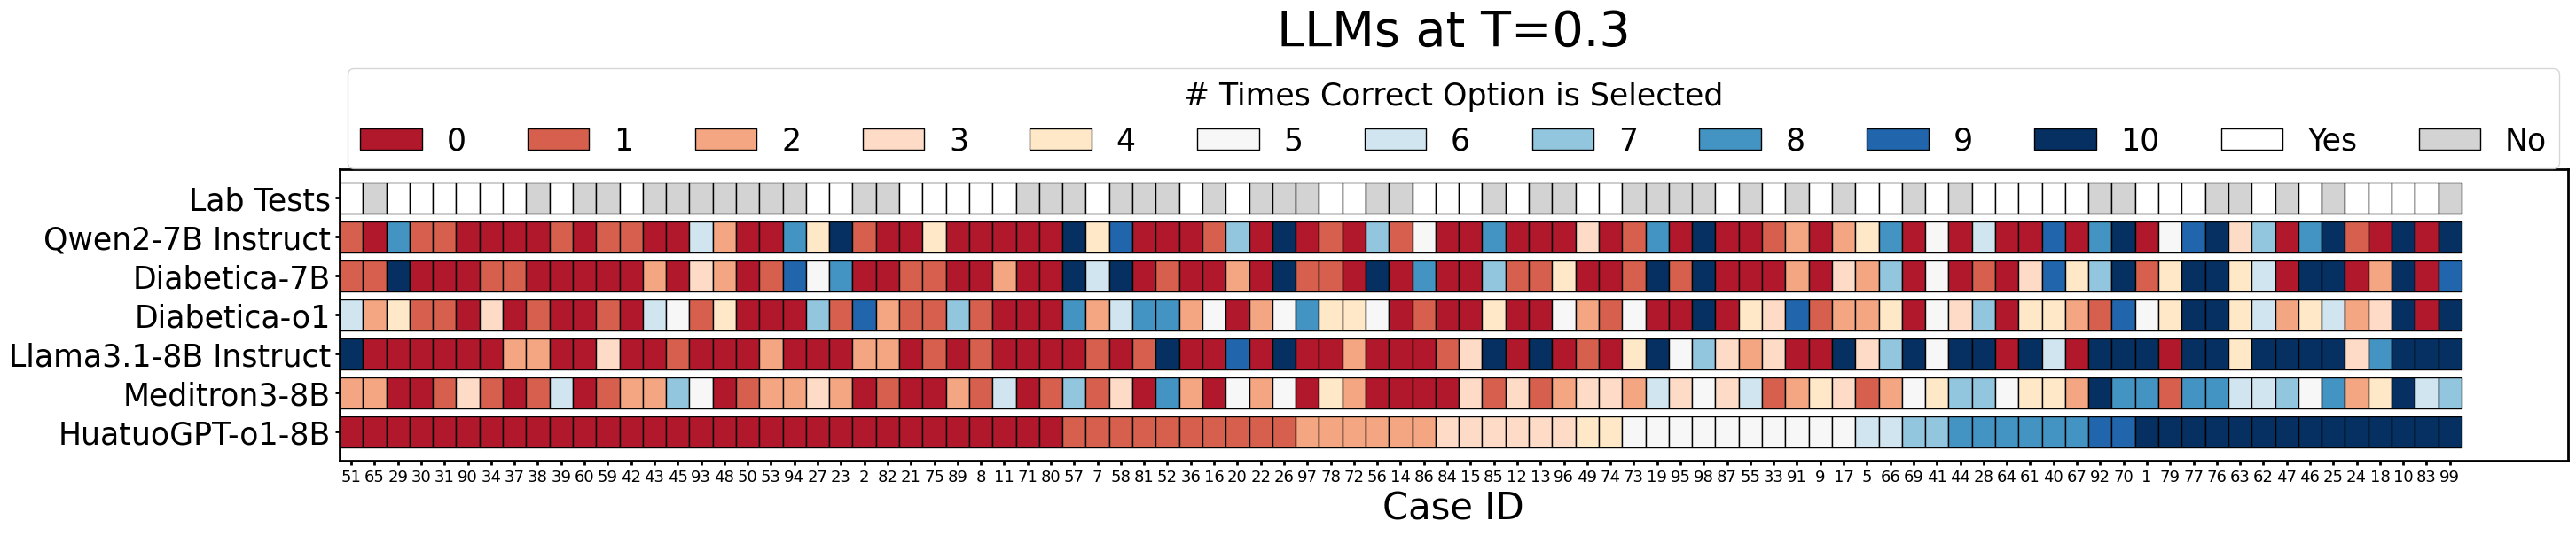

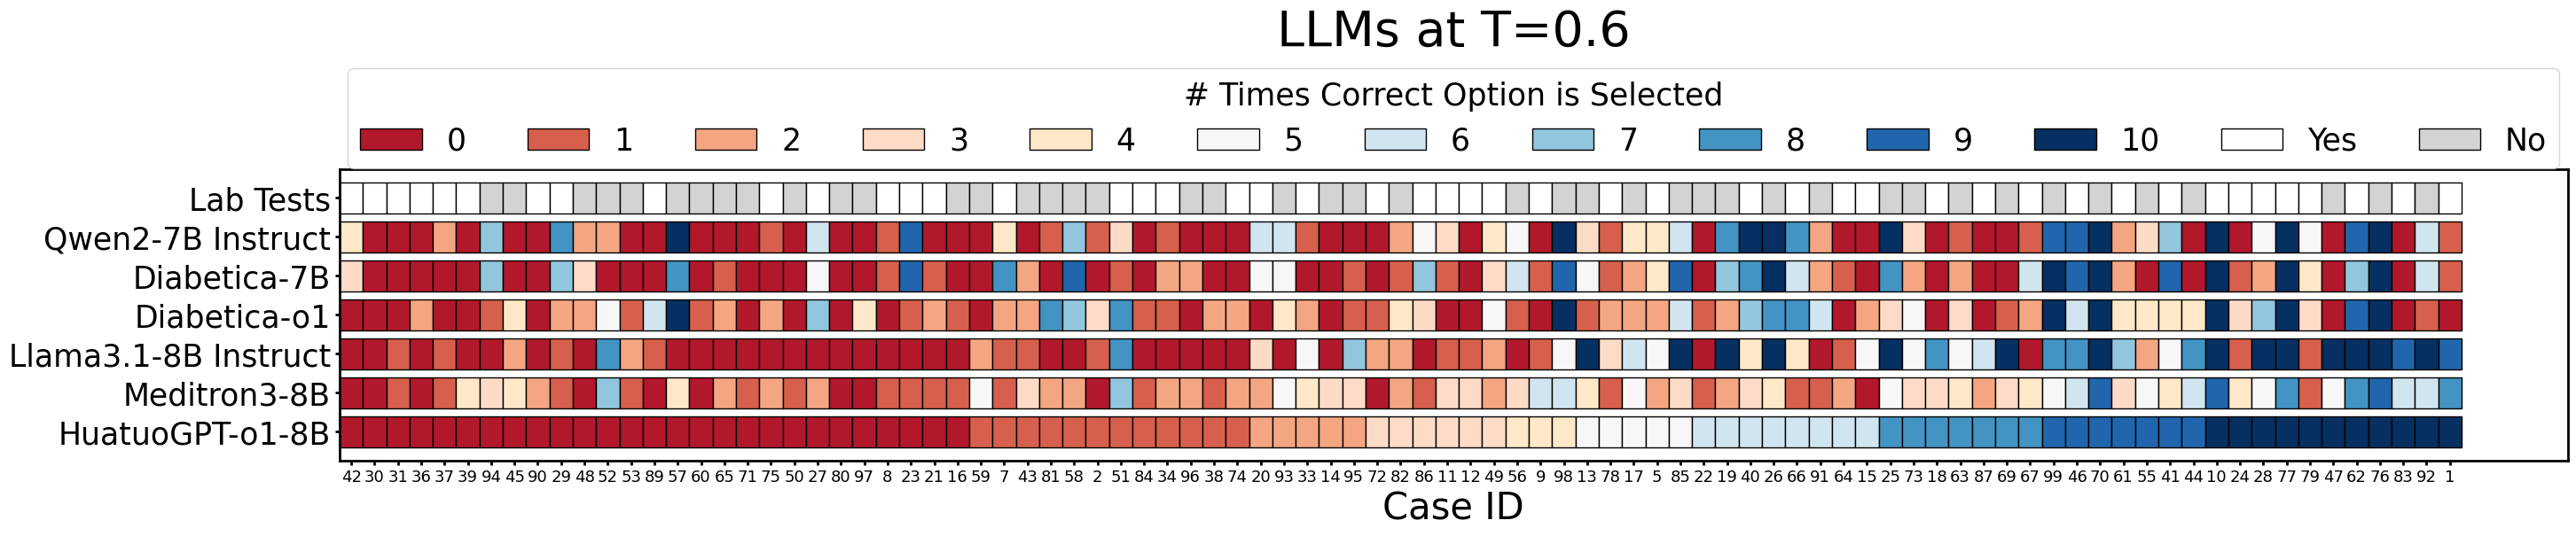

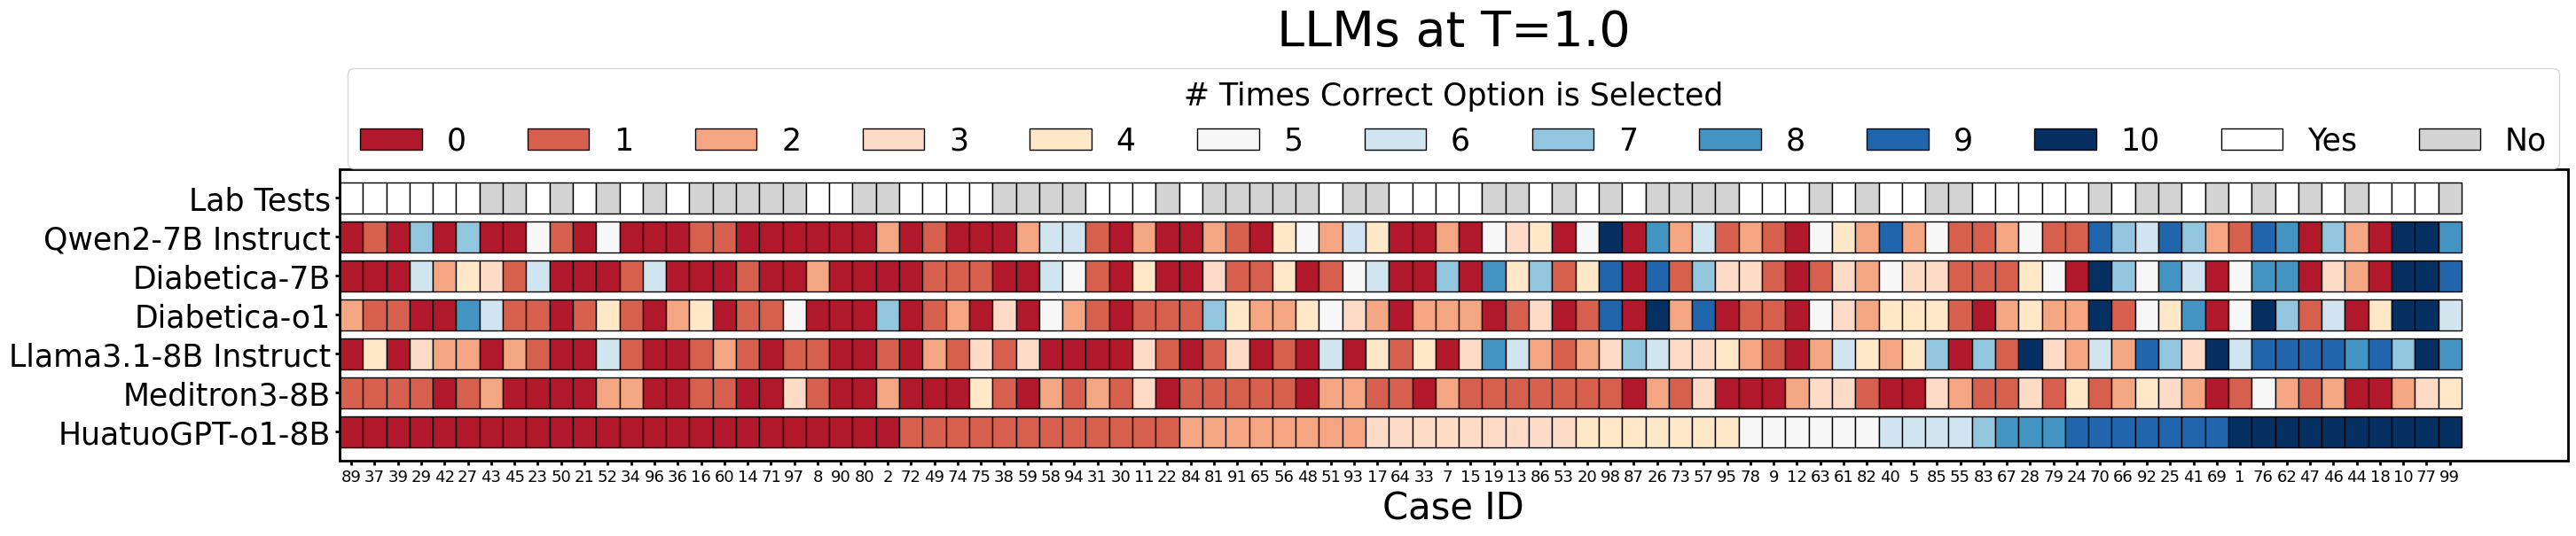

In [28]:
for id_t, t_ in enumerate(temperature_list):
    plotname = f"plots/responses_exp2_extensive_T={t_}.pdf"

    plot_singular_responses(comparison_mat, 
                            across_models=True, 
                            temp_id=id_t, 
                            model_id=None,
                            saveplot=True,
                            plotname=plotname)

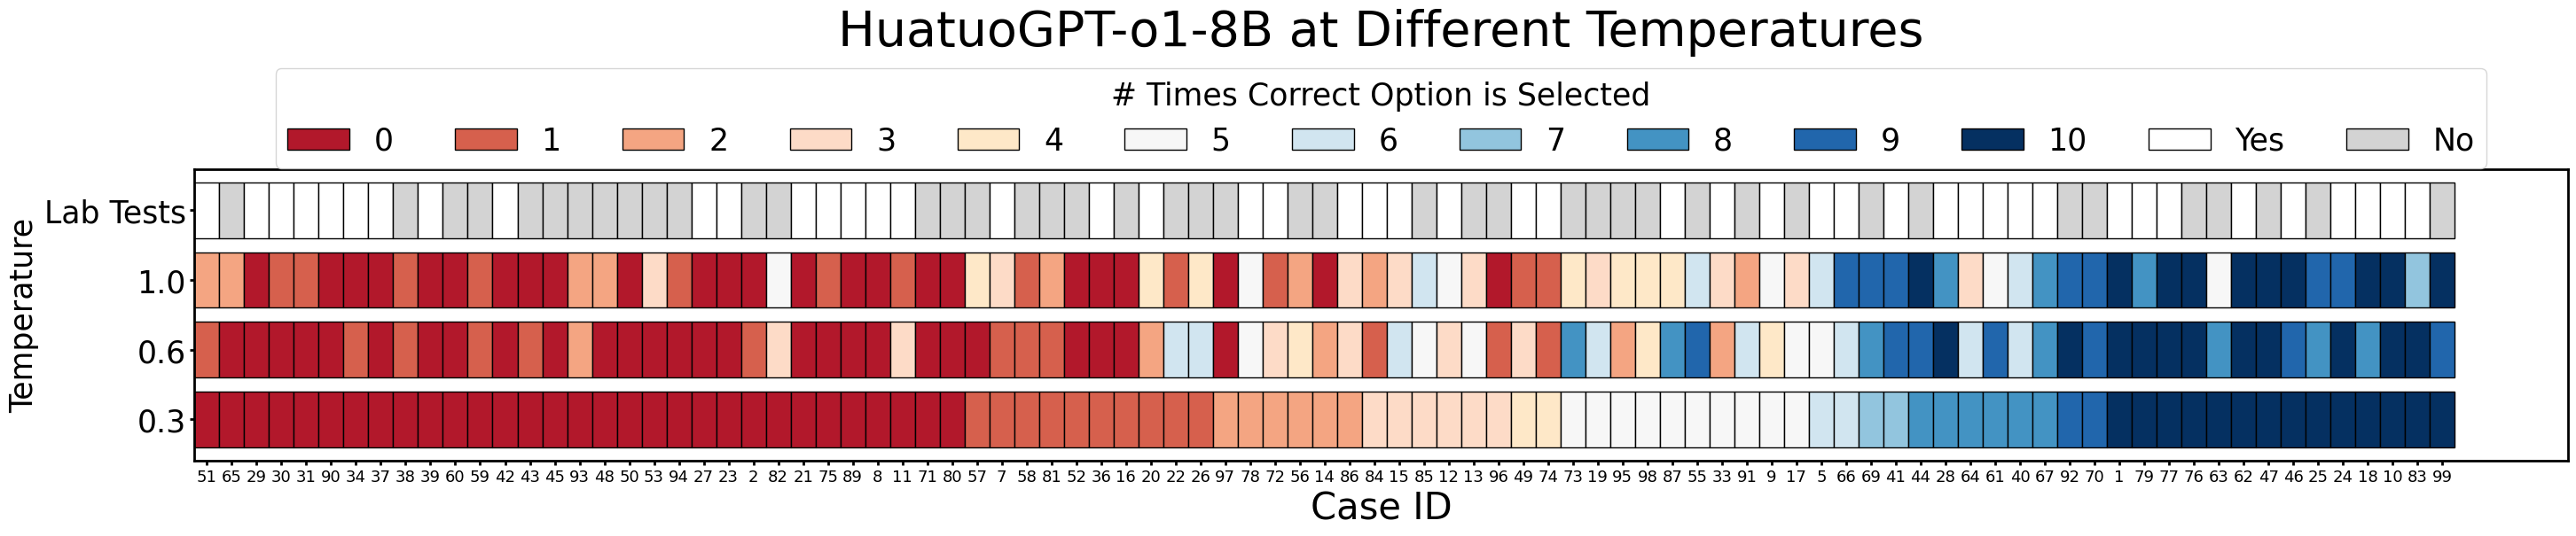

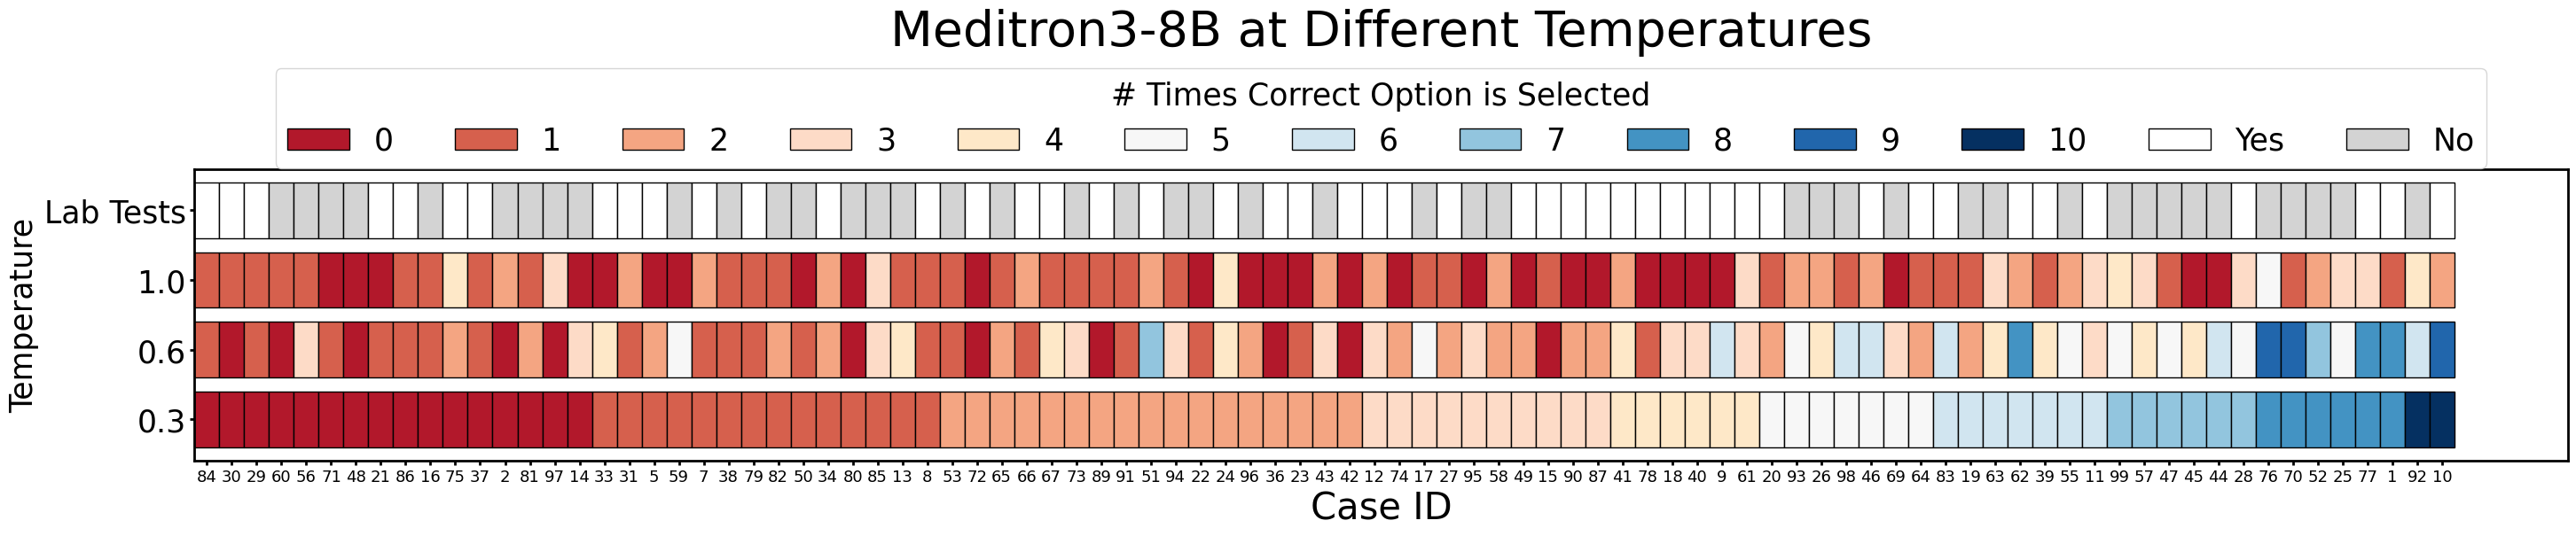

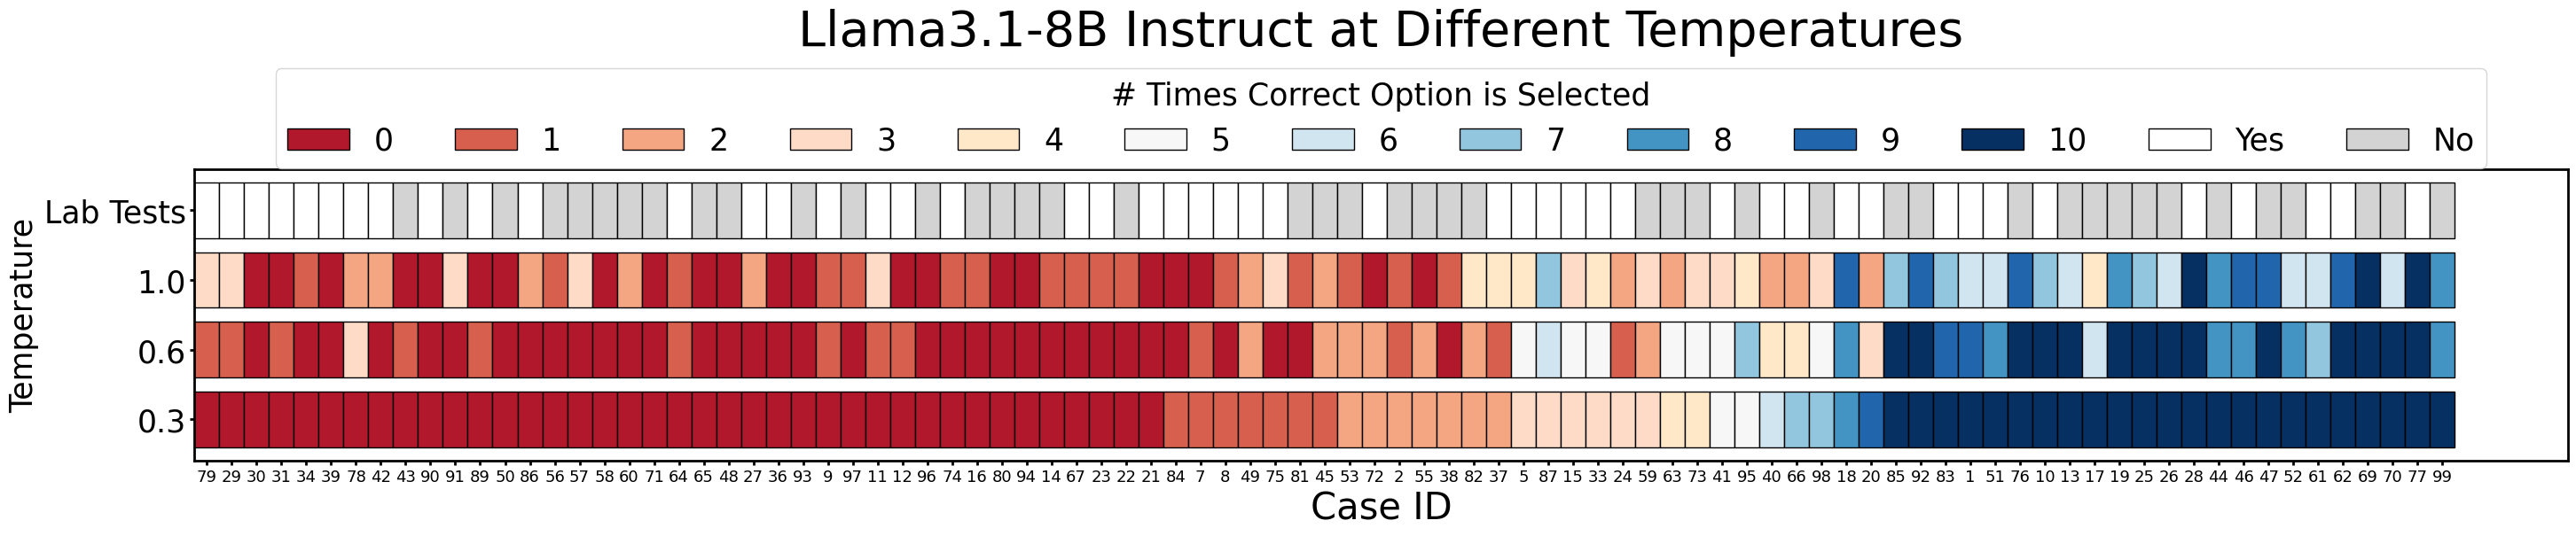

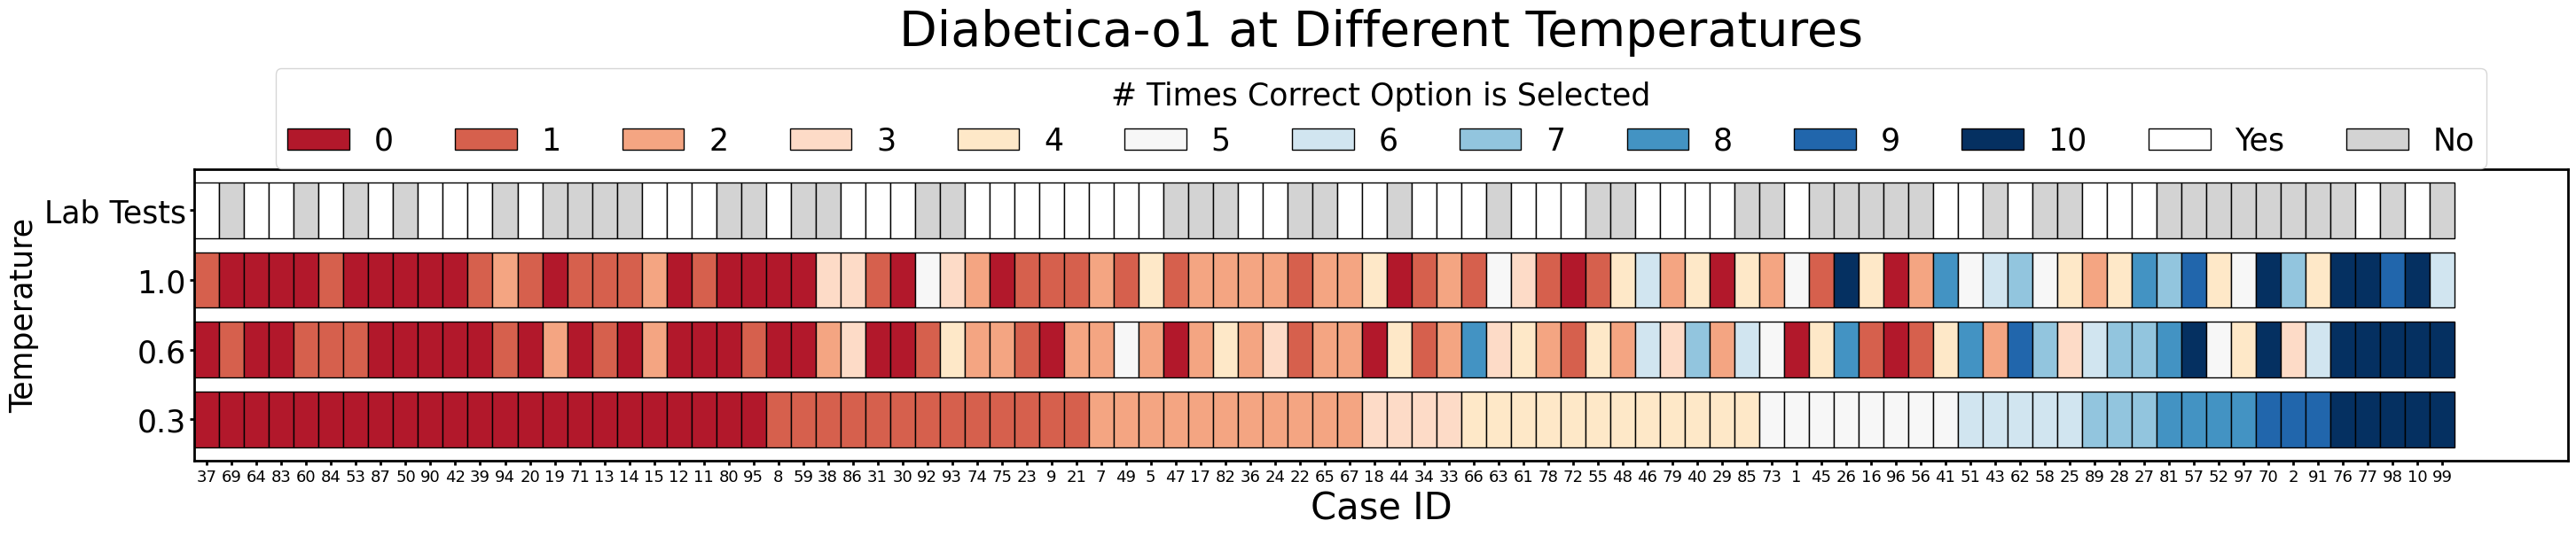

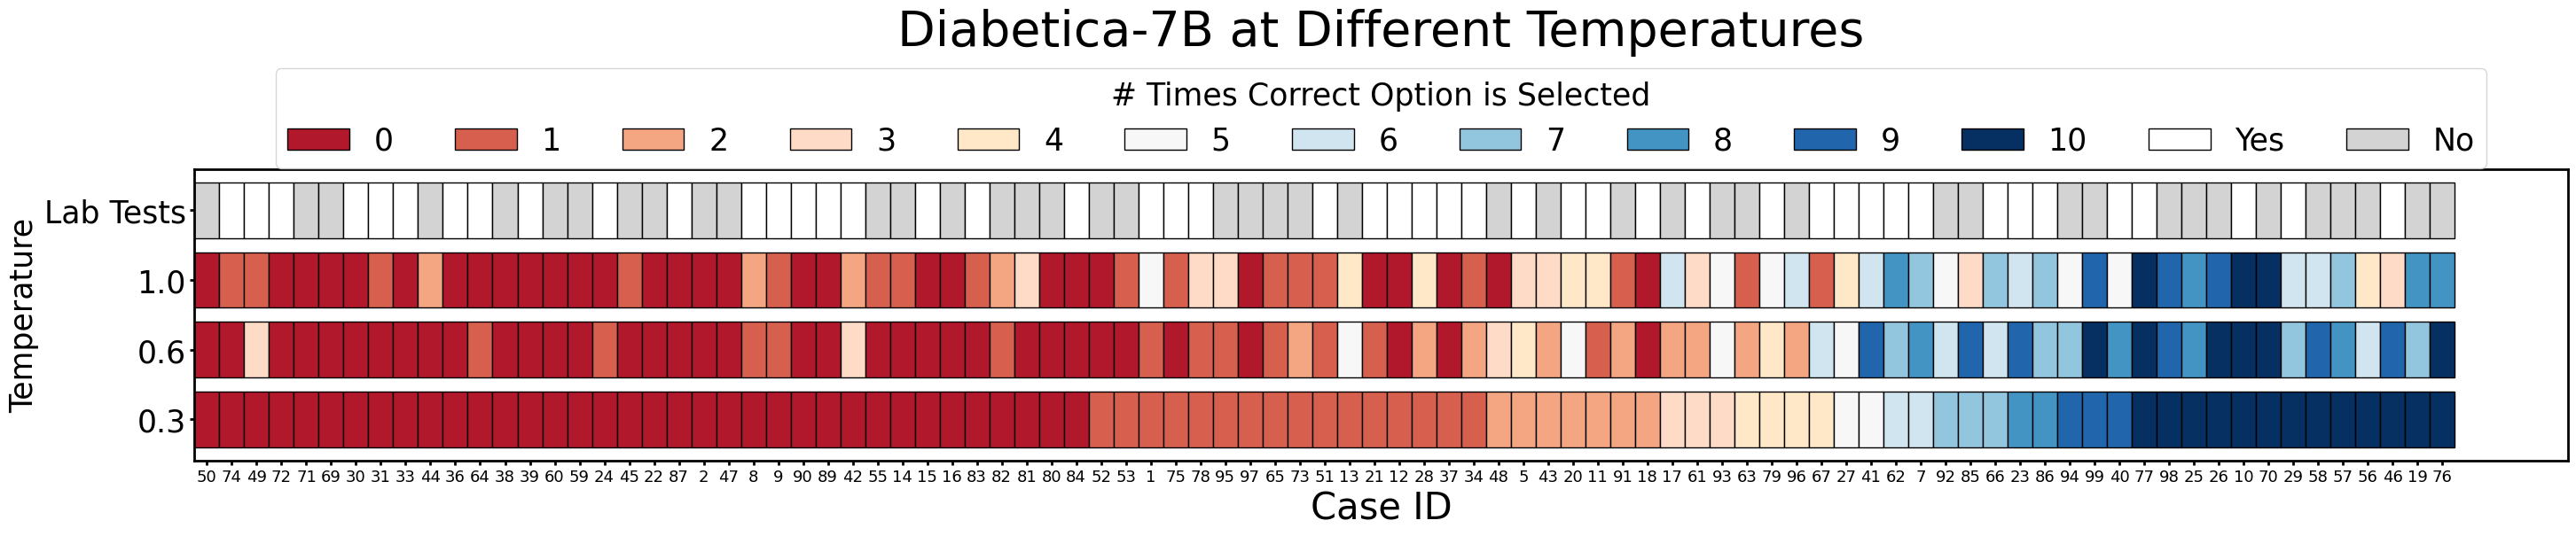

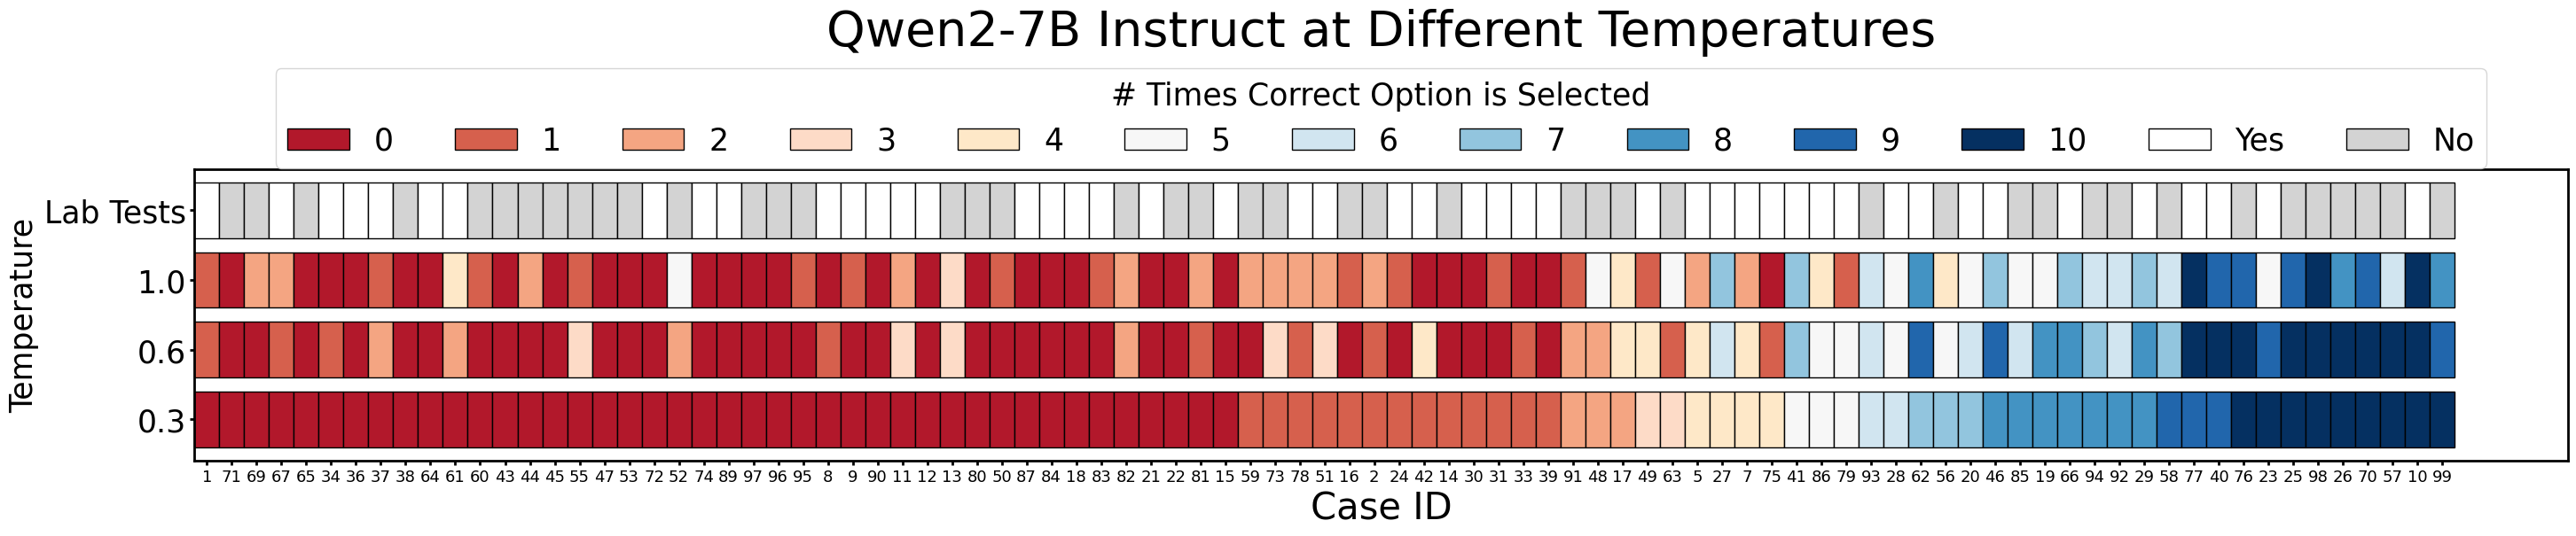

In [29]:
for id_m, m_ in enumerate(model_list):
    plotname = f"plots/responses_exp2_extensive_m={m_}.pdf"

    plot_singular_responses(comparison_mat, across_models=False, model_id=id_m,
                            saveplot=True, plotname=plotname)

In [30]:
# Compact summaries used for manuscript checks.
temperature_comparison = pd.DataFrame({
    "Huatuo T=0.6 > T=0.3": [(comparison_mat[1, 0] > comparison_mat[0, 0]).sum()],
    "Huatuo T=1.0 > T=0.3": [(comparison_mat[2, 0] > comparison_mat[0, 0]).sum()],
    "Huatuo T=1.0 > T=0.6": [(comparison_mat[2, 0] > comparison_mat[1, 0]).sum()],
    "Huatuo T=0.3 > T=1.0": [(comparison_mat[0, 0] > comparison_mat[2, 0]).sum()],
})

dominance_rows = []
for temp_idx, temperature in enumerate(temperature_list):
    for model_idx, model_name in enumerate(model_list):
        bm_best_or_tied = comparison_mat[temp_idx, model_idx] >= comparison_mat[temp_idx].max(axis=0)
        dominance_rows.append({
            "temperature": temperature,
            "model": model_name,
            "best_or_tied_cases": int(bm_best_or_tied.sum()),
        })

dominance_summary = pd.DataFrame(dominance_rows)
temperature_comparison, dominance_summary


(   Huatuo T=0.6 > T=0.3  Huatuo T=1.0 > T=0.3  Huatuo T=1.0 > T=0.6  \
 0                    30                    27                    27   
 
    Huatuo T=0.3 > T=1.0  
 0                    26  ,
     temperature                 model  best_or_tied_cases
 0           0.3       HuatuoGPT-o1-8B                  31
 1           0.3          Meditron3-8B                  21
 2           0.3  Llama3.1-8B Instruct                  34
 3           0.3          Diabetica-o1                  29
 4           0.3          Diabetica-7B                  20
 5           0.3     Qwen2-7B Instruct                  17
 6           0.6       HuatuoGPT-o1-8B                  33
 7           0.6          Meditron3-8B                  22
 8           0.6  Llama3.1-8B Instruct                  25
 9           0.6          Diabetica-o1                  29
 10          0.6          Diabetica-7B                  20
 11          0.6     Qwen2-7B Instruct                  22
 12          1.0       HuatuoGPT

In [31]:
# Distribution of the number of correct selections across 10 repetitions at T=0.3.
vals = pd.DataFrame(comparison_mat[0], index=model_list, columns=df_all['truth'].index)
possible_values = list(range(0, 11))
counts_per_row = vals.apply(
    lambda row: row.value_counts().reindex(possible_values, fill_value=0),
    axis=1,
).T
counts_per_col = counts_per_row.T
never_correct = (vals == 0).sum(axis=1)

counts_per_row, counts_per_col, never_correct


(    HuatuoGPT-o1-8B  Meditron3-8B  Llama3.1-8B Instruct  Diabetica-o1  \
 0                31            16                    39            23   
 1                10            14                     7            13   
 2                 6            17                     7            11   
 3                 6            10                     6             4   
 4                 2             6                     2            12   
 5                10             7                     2             8   
 6                 2             7                     1             5   
 7                 2             6                     2             3   
 8                 6             6                     1             4   
 9                 2             0                     1             3   
 10               14             2                    23             5   
 
     Diabetica-7B  Qwen2-7B Instruct  
 0             36                 42  
 1             16               

In [32]:
correct_consistent_tables = {}
for id_t, t_ in enumerate(temperature_list):
    result = np.zeros((len(model_file), 2), dtype=int)
    for id_m, m_ in enumerate(model_file):
        n_correct_10 = np.where(comparison_mat[id_t, id_m] == 10)[0].size
        n_consistent_10 = np.where(count_sel_list_and_t[id_t, id_m] == 10)[0].size
        result[id_m, :] = [n_correct_10, n_consistent_10 - n_correct_10]

    correct_consistent_tables[t_] = pd.DataFrame(
        result,
        index=model_list,
        columns=["# correct 10 times", "# consistently incorrect 10 times"],
    )

correct_consistent_tables


{0.3:                       # correct 10 times  # consistently incorrect 10 times
 HuatuoGPT-o1-8B                       14                                 11
 Meditron3-8B                           2                                  0
 Llama3.1-8B Instruct                  23                                 28
 Diabetica-o1                           5                                  4
 Diabetica-7B                          13                                 16
 Qwen2-7B Instruct                      9                                 25,
 0.6:                       # correct 10 times  # consistently incorrect 10 times
 HuatuoGPT-o1-8B                       11                                  7
 Meditron3-8B                           0                                  0
 Llama3.1-8B Instruct                  14                                 13
 Diabetica-o1                           7                                  3
 Diabetica-7B                           6                        

# Heatmaps and representations


# Answers Correctness Across Runs at Different Temperatures

Number of correct responses across each run.


<>:101: SyntaxWarning: invalid escape sequence '\ '
<>:102: SyntaxWarning: invalid escape sequence '\ '
<>:101: SyntaxWarning: invalid escape sequence '\ '
<>:102: SyntaxWarning: invalid escape sequence '\ '
/var/folders/y1/f506t3w53wx7929bx_prwqs00000gp/T/ipykernel_66911/3595783886.py:101: SyntaxWarning: invalid escape sequence '\ '
  fig.supxlabel('$\\bf{Mean\ Accuracy\ Across\ 10\ Runs}$', fontsize=35)
/var/folders/y1/f506t3w53wx7929bx_prwqs00000gp/T/ipykernel_66911/3595783886.py:102: SyntaxWarning: invalid escape sequence '\ '
  fig.supylabel('$\\bf{Consistency\ of\ Majority\ Vote}$', fontsize=35, x=0.05)
/var/folders/y1/f506t3w53wx7929bx_prwqs00000gp/T/ipykernel_66911/3595783886.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i_t, i_m].set_xticklabels([f"{t/10:.1f}" for t in ticks], fontsize=20)
/var/folders/y1/f506t3w53wx7929bx_prwqs00000gp/T/ipykernel_66911/3595783886.py:97: UserWarning: 

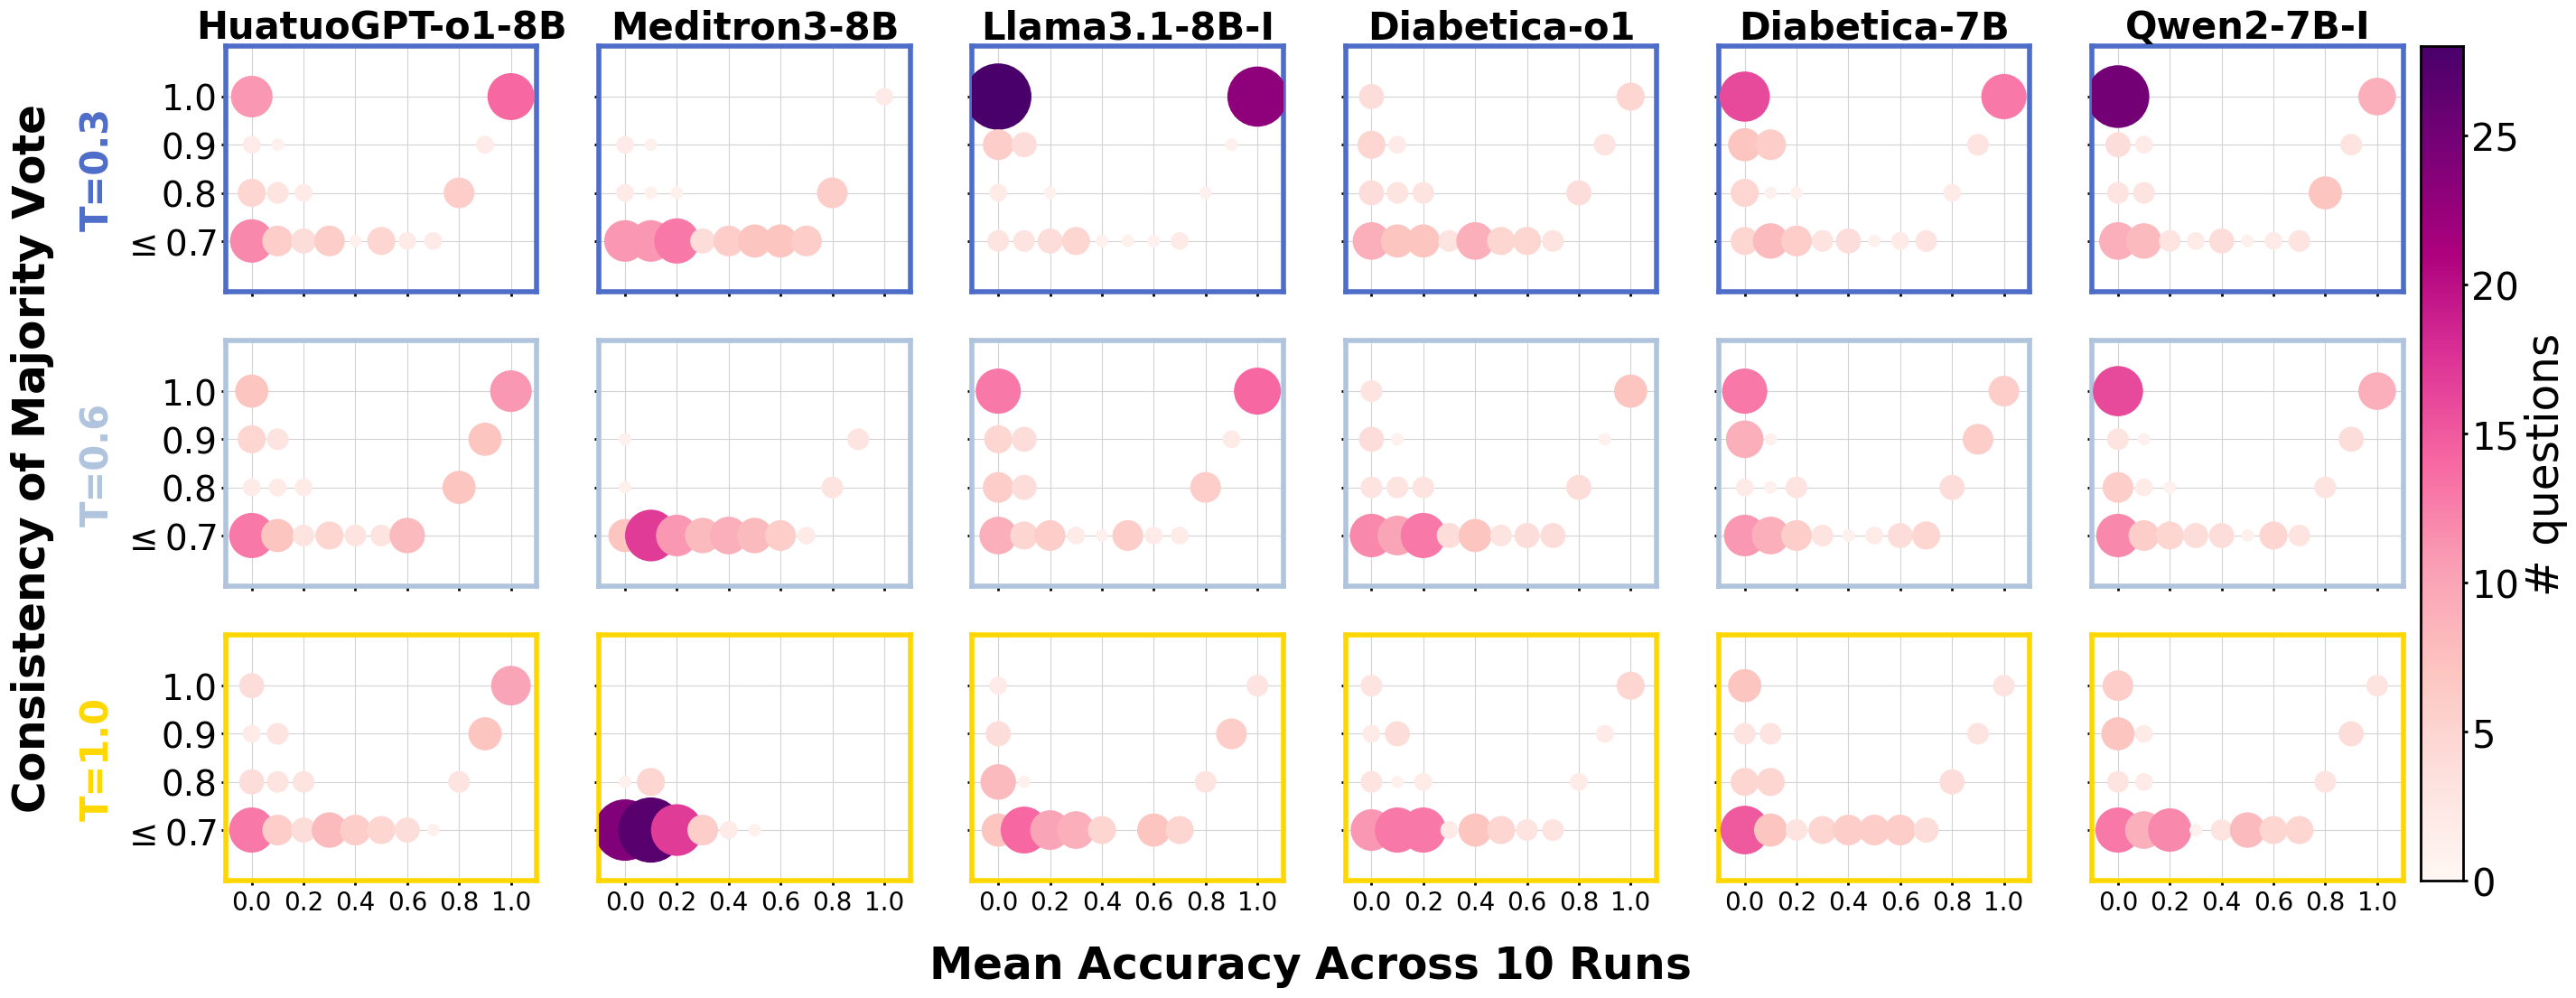

In [35]:
# model_list
# results

fig, ax = plt.subplots(figsize=(32, 12), nrows=3, ncols=6, sharex=True, sharey=True)
row_colors = ['#bbbbbb', '#777777', '#000000']  # or use more steps if needed
row_colors = [
    (0.3060, 0.4285, 0.7891),
    'lightsteelblue',
    'gold'
]

global_max = 0
for i_t, t in enumerate(temperature_list):
    for i_m in [0,2,3,5]: # change
        data_heatmap = np.zeros((8, 11))
        bm_majority = ~np.isnan(count_sel_list_and_t[i_t][i_m])
        for consistency, correctness in zip(count_sel_list_and_t[i_t][i_m][bm_majority],
                                            comparison_mat[i_t][i_m][bm_majority]):
            data_heatmap[int(consistency)-3, int(correctness)] += 1
        data_heatmap = np.vstack((data_heatmap[:5,:].sum(axis=0).reshape(1,-1), 
                                  data_heatmap[5:,:]))
        tmp_max = np.max(data_heatmap) 
        # print(tmp_max)
        if tmp_max > global_max:
            global_max = tmp_max


model_list_plot2 = ["HuatuoGPT-o1-8B", "Meditron3-8B", "Llama3.1-8B-I", "Diabetica-o1", "Diabetica-7B", "Qwen2-7B-I"]
for i_t, t in enumerate(temperature_list):
    df_heatmap_list = []
    
    for i_m in range(len(model_list)): # change

        data_heatmap = np.zeros((8, 11))
        bm_majority = ~np.isnan(count_sel_list_and_t[i_t][i_m]) # there is a majority

        for consistency, correctness in zip(count_sel_list_and_t[i_t][i_m][bm_majority], # count of majority vote
                                            comparison_mat[i_t][i_m][bm_majority]): # count of correct class

            data_heatmap[int(consistency)-3, int(correctness)] += 1
            
        data_heatmap = np.vstack((data_heatmap[:5,:].sum(axis=0).reshape(1,-1), 
                                  data_heatmap[5:,:]))
        data_heatmap = data_heatmap[::-1]
        data = pd.DataFrame(data_heatmap, columns=range(11),
                            index=[1., 0.9, 0.8, r'$\leq 0.7$'])

        ax[i_t, i_m].spines['bottom'].set_linewidth(4)
        ax[i_t, i_m].spines['left'].set_linewidth(4)
        ax[i_t, i_m].spines['top'].set_linewidth(4)
        ax[i_t, i_m].spines['right'].set_linewidth(4)
        ax[i_t, i_m].tick_params(width=2)

        for spine in ax[i_t, i_m].spines.values():
            spine.set_color(row_colors[i_t])
            
        x_labels = data.columns
        y_labels = data.index
        x_pos, y_pos, sizes, texts = [], [], [], []
        ax[i_t, i_m].grid(True, color='lightgray')
        
        for i, y in enumerate(y_labels):
            for j, x in enumerate(x_labels):
                val = int(data.iloc[i, j])
                if val > 0:
                    x_pos.append(j)
                    y_pos.append(i)
                    sizes.append(val * 100)  # adjust scale
                    texts.append(str(val))

        scatter = ax[i_t, i_m].scatter(
            x_pos, y_pos,
            s=sizes, 
            c=[int(t) for t in texts],  # values to color by
            cmap="RdPu", 
            edgecolors='none', 
            marker='o', 
            zorder=4,
            vmin=0, 
            vmax=global_max,
            # cmap='viridis'  # filled blobs
        )

        # Add number labels to each blob
        # for (x, y, t) in zip(x_pos, y_pos, texts):
        #    ax[i_t, i_m].text(x, y, t, color='black', ha='center', va='center', fontsize=12, zorder=5)

        # === Ticks and labels ===
        ax[i_t, i_m].margins(x=0.3, y=0.35)  # add 10% padding on both axes
        # ax[i_t, i_m].set_xticks(range(len(x_labels)))
        # ax[i_t, i_m].set_xticklabels(/10, fontsize=28)
        ax[i_t, i_m].set_yticks(range(len(y_labels)))
        ax[i_t, i_m].set_yticklabels(y_labels, fontsize=28)
        ax[0, i_m].set_title(model_list_plot2[i_m], fontsize=30, weight='bold')
        ax[i_t, i_m].set_xlim([-1,11])
        ticks = ax[i_t, i_m].get_xticks()
        ax[i_t, i_m].set_xticklabels([f"{t/10:.1f}" for t in ticks], fontsize=20)
    ax[i_t, 0].set_ylabel(f"T={t}", fontsize=30, weight='bold', color=row_colors[i_t], 
                          # rotation='horizontal'
                         )
fig.supxlabel('$\\bf{Mean\ Accuracy\ Across\ 10\ Runs}$', fontsize=35)
fig.supylabel('$\\bf{Consistency\ of\ Majority\ Vote}$', fontsize=35, x=0.05)

ax[0, 0].invert_yaxis()  # match heatmap orientation

sm = cm.ScalarMappable(cmap='RdPu', norm=plt.Normalize(vmin=0, vmax=global_max))
sm.set_array([])  # required dummy array

# Add colorbar to the figure
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.008)
cbar.set_label('# questions', fontsize=35)
for spine in cbar.ax.spines.values():
    spine.set_visible(True)
cbar.ax.tick_params(labelsize=30, width=2)
cbar.ax.spines['bottom'].set_linewidth(2)
cbar.ax.spines['left'].set_linewidth(2)
cbar.ax.spines['top'].set_linewidth(2)
cbar.ax.spines['right'].set_linewidth(2)

# plt.tight_layout()
plt.savefig("plots/test2.pdf")
plt.show()

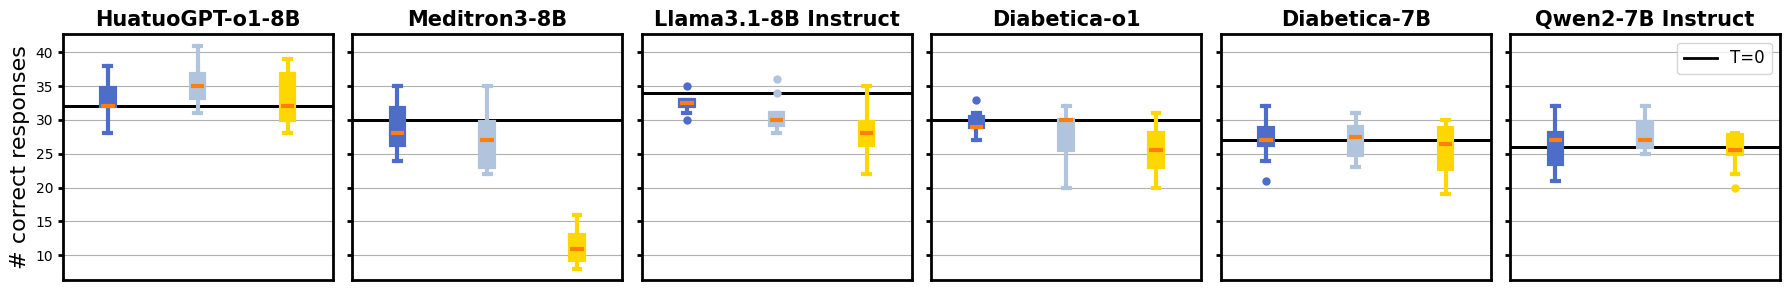

In [36]:
fig, ax = plt.subplots(figsize=(18,3), ncols=len(model_list), sharey=True)

boxprops = dict(linewidth=3)
medianprops = dict(linewidth=3)
whiskerprops = dict(linewidth=3)
capprops = dict(linewidth=3)
flierprops = dict(marker='o', markersize=5, linestyle='none')

color_t0 = 'black'
colors_list = [
    (0.3060, 0.4285, 0.7891),
    'lightsteelblue',
    'gold'
]


for j, t in enumerate(temperature_list): 
    # each temperature has a different color
    box_color = colors_list[j]

    for i, (m, m_name) in enumerate(zip(model_file, model_list)):
        ax[i].spines['bottom'].set_linewidth(2)
        ax[i].spines['left'].set_linewidth(2)
        ax[i].spines['top'].set_linewidth(2)
        ax[i].spines['right'].set_linewidth(2)
        ax[i].tick_params(width=2)
        ax[i].grid()

        lab = "T=0" if (i == 5 and j == 2) else None
        ax[i].axhline(results.loc[f"{m}-prompt1"]['# correct'], color=color_t0,
                          linewidth=2, linestyle='-', label=lab, zorder=2)

        flierprops = dict(marker='o', markersize=5, linestyle='none', 
                          markerfacecolor=box_color, markeredgecolor=box_color)

        bp = ax[i].boxplot(bm_across_models_and_t[j][i], 
                           positions=[j],
                           boxprops=boxprops, 
                           medianprops=medianprops,
                           whiskerprops=whiskerprops, 
                           capprops=capprops, 
                           flierprops=flierprops,
                           patch_artist=True, 
                           tick_labels=None,
                           # legend=lab,
                           zorder=4)
                
        bp['boxes'][0].set_facecolor(box_color)
        for element in ['boxes', 'whiskers', 'caps']: #, 'medians']:
            for b in bp[element]:
                b.set_color(box_color)
                b.set_linewidth(3)
        
        if t == temperature_list[-1]:
            ax[i].set_title(m_name, fontsize=15, weight='bold')
        ax[i].set_xticks([])          # removes tick locations
        ax[i].set_xticklabels([])     # removes labels (just in case)


tick = ax[0].yaxis.get_major_ticks()
# for t in tick:
#    t.label.set_fontsize(11) 
ax[0].set_ylabel("# correct responses", fontsize=16)

# legend
line_T0 = mlines.Line2D([], [], color='black', label='T=0')
# box_handles = [
#    mpatches.Patch(facecolor=color, edgecolor=color, label=f'T={temperature_list[k]}')
#    for k, color in enumerate(colors_list)]
# handles = line_T0 # [line_T0]  + box_handles
# ax[-1].legend(handles=handles, fontsize='large') #, loc='center left', bbox_to_anchor=(1, 0.5))
ax[-1].legend(fontsize='large')

plt.tight_layout()
# plt.savefig(f"plots/temperatures_distribution_runs.pdf")

## Mean consistency and accuracy with bootstrap

In [37]:
def bootstrap_mean_ci_fast(x, B=10000, ci=95, random_state=None):
    """
    Vectorized bootstrap CI for the mean.
    """
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)
    n = len(x)

    # Bootstrap resampling indices
    indices = rng.integers(0, n, size=(B, n))
    boot_samples = x[indices]
    boot_means = boot_samples.mean(axis=1)

    alpha = (100 - ci) / 2
    ci_low, ci_high = np.percentile(boot_means, [alpha, 100 - alpha])

    return x.mean(), ci_low, ci_high

In [39]:
# what is the accuracy for each run, model, temperature

consistency = []

for t_ in temperature_list:
    consistency_list = []

    for m_ in model_file: 
        # for each model and temperature we load the excel and retrieve information
        rep_df = pd.read_excel(f"{path_repetitions}/T={t_}/{m_}/{m_}_promptID_001_repetitions.xlsx",
                               header=None, index_col=0)
        
        consistency_sel = []
        for id_row, row in enumerate(rep_df.values):
            row = row[~pd.isna(row)]
            _, count = max_frequency_string(row, identify_majority=False)
            consistency_sel.append(count)
        consistency_list.append(np.array(consistency_sel))
        
    consistency.append(consistency_list)
    
consistency = np.array(consistency) / 10

mean_consistency_estimate = np.zeros((3,6))
consistency_lo = np.zeros_like(mean_consistency_estimate)
consistency_hi = np.zeros_like(mean_consistency_estimate)

for m in range(6):
    for t in range(3):
        mean_C, ci_lo, ci_hi = bootstrap_mean_ci_fast(consistency[t][m], B=10000)
        print(f"T={t}, Model={m}: mean={mean_C:.3f}, CI=[{ci_lo:.3f}, {ci_hi:.3f}]")
        mean_consistency_estimate[t, m] = mean_C
        consistency_lo[t, m] = ci_lo
        consistency_hi[t, m] = ci_hi
        # print("T: ", np.mean(consistency[t][m])/10, (consistency[t][m]/10).std())
    print("-----------------")

T=0, Model=0: mean=0.749, CI=[0.710, 0.790]
T=1, Model=0: mean=0.736, CI=[0.695, 0.777]
T=2, Model=0: mean=0.703, CI=[0.663, 0.743]
-----------------
T=0, Model=1: mean=0.554, CI=[0.518, 0.591]
T=1, Model=1: mean=0.501, CI=[0.468, 0.535]
T=2, Model=1: mean=0.536, CI=[0.508, 0.565]
-----------------
T=0, Model=2: mean=0.855, CI=[0.810, 0.897]
T=1, Model=2: mean=0.770, CI=[0.726, 0.812]
T=2, Model=2: mean=0.623, CI=[0.581, 0.663]
-----------------
T=0, Model=3: mean=0.651, CI=[0.609, 0.691]
T=1, Model=3: mean=0.653, CI=[0.613, 0.693]
T=2, Model=3: mean=0.621, CI=[0.581, 0.662]
-----------------
T=0, Model=4: mean=0.785, CI=[0.742, 0.826]
T=1, Model=4: mean=0.738, CI=[0.698, 0.778]
T=2, Model=4: mean=0.647, CI=[0.602, 0.690]
-----------------
T=0, Model=5: mean=0.798, CI=[0.755, 0.837]
T=1, Model=5: mean=0.743, CI=[0.700, 0.786]
T=2, Model=5: mean=0.671, CI=[0.631, 0.712]
-----------------


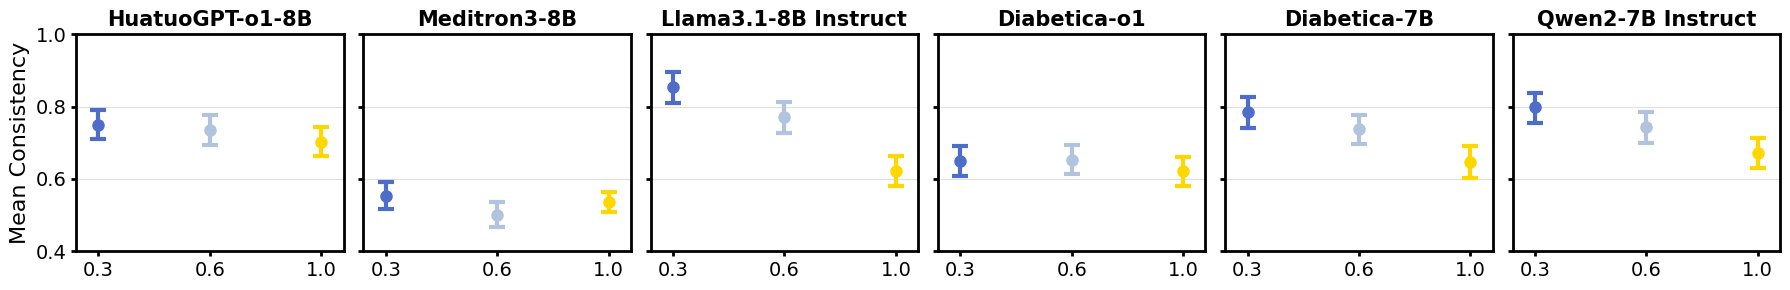

In [40]:
fig, ax = plt.subplots(
    figsize=(18, 3),
    ncols=len(model_list),
    sharey=True
)

colors_list = [
    (0.3060, 0.4285, 0.7891),  # T = 0.3
    "lightsteelblue",          # T = 0.6
    "gold"                     # T = 1.0
]

for i, m_name in enumerate(model_list):

    # Styling (match your existing plots)
    for spine in ax[i].spines.values():
        spine.set_linewidth(2)
    ax[i].tick_params(width=2)
    ax[i].grid(axis="y", alpha=0.4)

    for t in range(3):
        mean = mean_consistency_estimate[t, i]
        lo   = consistency_lo[t, i]
        hi   = consistency_hi[t, i]

        ax[i].errorbar(
            t,
            mean,
            yerr=[[mean - lo], [hi - mean]],
            fmt='o',
            color=colors_list[t],
            ecolor=colors_list[t],
            elinewidth=3,
            capsize=6,
            capthick=3,
            markersize=8,
            zorder=5
        )

    ax[i].set_title(m_name, fontsize=15, weight='bold')
    ax[i].set_xticks([0,1,2], [0.3, 0.6, 1.0], fontsize=14)
    ax[i].set_ylim(0.4, 1.0)
    ax[i].set_xlim([-0.2,2.2])
    
ax[0].tick_params(axis='y', labelsize=14) 
ax[0].set_ylabel("Mean Consistency", fontsize=16)

plt.tight_layout()
# plt.savefig("plots/mean_consistency_bootstrap_ci.pdf")
plt.show()

In [41]:
mean_accuracy_estimate = np.zeros((3,6))
accuracy_lo = np.zeros_like(mean_accuracy_estimate)
accuracy_hi = np.zeros_like(mean_accuracy_estimate)

for m in range(6):
    for t in range(3):
        mean_acc, acc_lo, acc_hi = bootstrap_mean_ci_fast(comparison_mat[t][m]/10, B=10000)
        print(f"T={t}, Model={m}: mean={mean_acc:.3f}, CI=[{acc_lo:.3f}, {acc_hi:.3f}]")
        mean_accuracy_estimate[t, m] = mean_acc
        accuracy_lo[t, m] = acc_lo
        accuracy_hi[t, m] = acc_hi
        # print("T: ", np.mean(consistency[t][m])/10, (consistency[t][m]/10).std())
    print("-----------------")

T=0, Model=0: mean=0.363, CI=[0.286, 0.443]
T=1, Model=0: mean=0.389, CI=[0.311, 0.466]
T=2, Model=0: mean=0.364, CI=[0.291, 0.437]
-----------------
T=0, Model=1: mean=0.318, CI=[0.264, 0.373]
T=1, Model=1: mean=0.298, CI=[0.252, 0.346]
T=2, Model=1: mean=0.126, CI=[0.102, 0.152]
-----------------
T=0, Model=2: mean=0.356, CI=[0.271, 0.445]
T=1, Model=2: mean=0.338, CI=[0.260, 0.420]
T=2, Model=2: mean=0.310, CI=[0.248, 0.375]
-----------------
T=0, Model=3: mean=0.324, CI=[0.263, 0.387]
T=1, Model=3: mean=0.303, CI=[0.242, 0.370]
T=2, Model=3: mean=0.280, CI=[0.223, 0.343]
-----------------
T=0, Model=4: mean=0.298, CI=[0.222, 0.376]
T=1, Model=4: mean=0.299, CI=[0.229, 0.373]
T=2, Model=4: mean=0.281, CI=[0.220, 0.346]
-----------------
T=0, Model=5: mean=0.288, CI=[0.215, 0.366]
T=1, Model=5: mean=0.305, CI=[0.233, 0.380]
T=2, Model=5: mean=0.279, CI=[0.218, 0.344]
-----------------


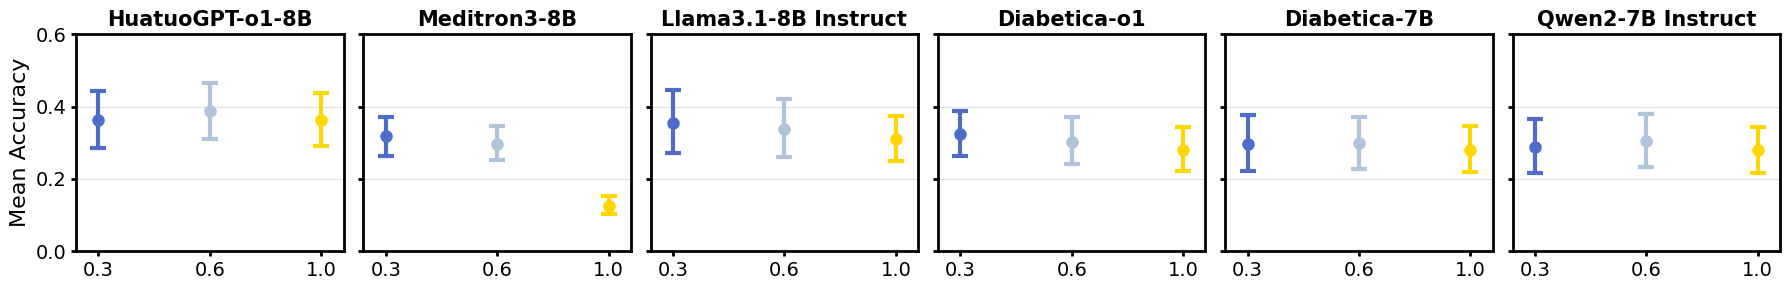

In [42]:
fig, ax = plt.subplots(
    figsize=(18, 3),
    ncols=len(model_list),
    sharey=True
)

colors_list = [
    (0.3060, 0.4285, 0.7891),  # T = 0.3
    "lightsteelblue",          # T = 0.6
    "gold"                     # T = 1.0
]

for i, m_name in enumerate(model_list):

    # Styling (match your existing plots)
    for spine in ax[i].spines.values():
        spine.set_linewidth(2)
    ax[i].tick_params(width=2)
    ax[i].grid(axis="y", alpha=0.4)

    for t in range(3):
        mean = mean_accuracy_estimate[t, i]
        lo   = accuracy_lo[t, i]
        hi   = accuracy_hi[t, i]

        ax[i].errorbar(
            t,
            mean,
            yerr=[[mean - lo], [hi - mean]],
            fmt='o',
            color=colors_list[t],
            ecolor=colors_list[t],
            elinewidth=3,
            capsize=6,
            capthick=3,
            markersize=8,
            zorder=5
        )

    ax[i].set_title(m_name, fontsize=15, weight='bold')
    ax[i].set_xticks([0,1,2], [0.3, 0.6, 1.0], fontsize=14)
    ax[i].set_ylim(0., 0.6)
    ax[i].set_xlim([-0.2,2.2])
    
ax[0].tick_params(axis='y', labelsize=14) 
ax[0].set_ylabel("Mean Accuracy", fontsize=16)

plt.tight_layout()
# plt.savefig("plots/mean_consistency_bootstrap_ci.pdf")
plt.show()

In [46]:
model_list, model_list_plot2

(['HuatuoGPT-o1-8B',
  'Meditron3-8B',
  'Llama3.1-8B Instruct',
  'Diabetica-o1',
  'Diabetica-7B',
  'Qwen2-7B Instruct'],
 ['HuatuoGPT-o1-8B',
  'Meditron3-8B',
  'Llama3.1-8B-I',
  'Diabetica-o1',
  'Diabetica-7B',
  'Qwen2-7B-I'])

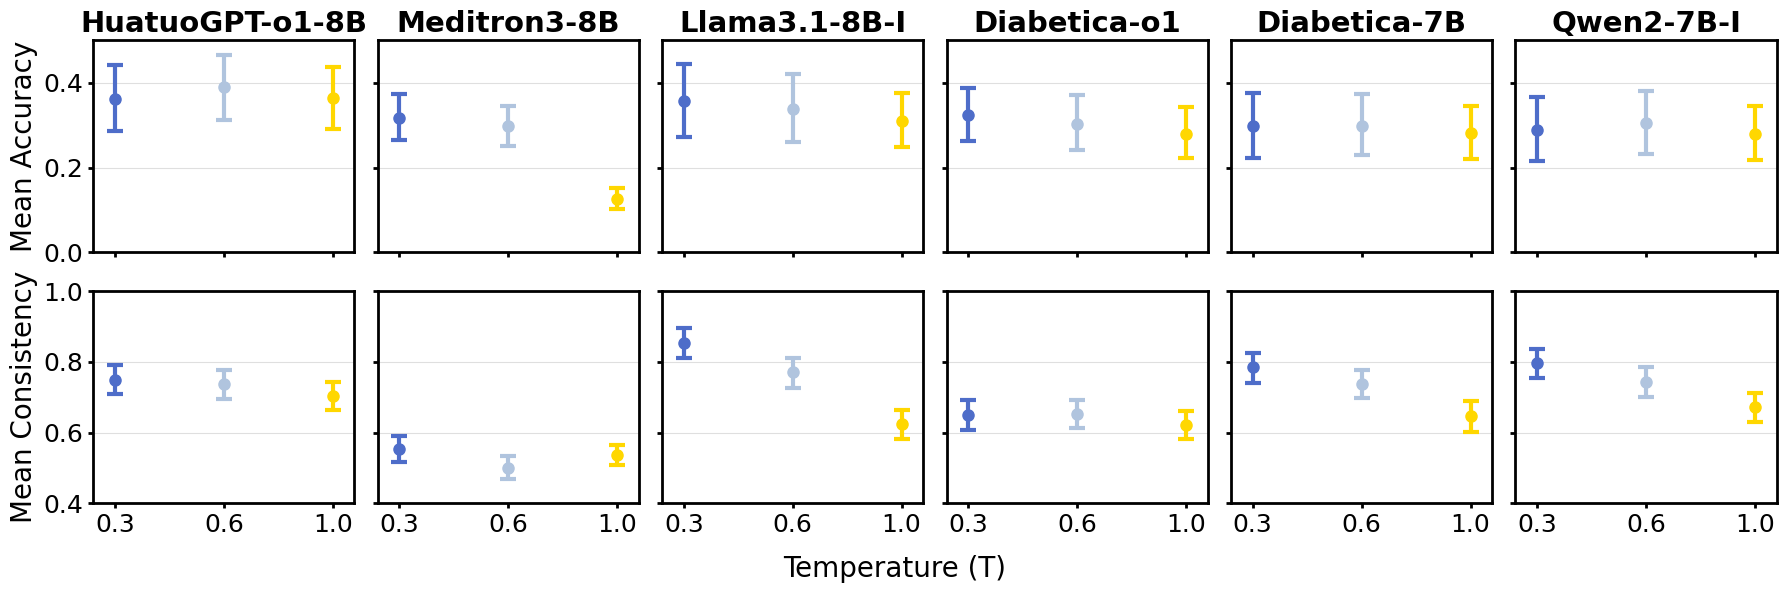

In [55]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(
    figsize=(18, 6),
    nrows=2,
    ncols=len(model_list),
    sharex=True, sharey='row'
)

colors_list = [
    (0.3060, 0.4285, 0.7891),  # T = 0.3
    "lightsteelblue",          # T = 0.6
    "gold"                     # T = 1.0
]

temps = [0.3, 0.6, 1.0]
x_positions = [0, 1, 2]

for i, m_name in enumerate(model_list):

    for row in range(2):
        for spine in ax[row, i].spines.values():
            spine.set_linewidth(2)
        ax[row, i].tick_params(width=2)
        ax[row, i].grid(axis="y", alpha=0.4)
        ax[row, i].set_xlim([-0.2, 2.2])

    # ---------- TOP ROW: ACCURACY ----------
    for t in range(3):
        mean = mean_accuracy_estimate[t, i]
        lo   = accuracy_lo[t, i]
        hi   = accuracy_hi[t, i]

        ax[0, i].errorbar(
            x_positions[t],
            mean,
            yerr=[[mean - lo], [hi - mean]],
            fmt='o',
            color=colors_list[t],
            ecolor=colors_list[t],
            elinewidth=3,
            capsize=6,
            capthick=3,
            markersize=8,
            zorder=5
        )

    ax[0, i].set_ylim(0.0, 0.6)
    ax[0, i].set_title(model_list_plot2[i], fontsize=21, weight='bold')

    # ---------- BOTTOM ROW: CONSISTENCY ----------
    for t in range(3):
        mean = mean_consistency_estimate[t, i]
        lo   = consistency_lo[t, i]
        hi   = consistency_hi[t, i]

        ax[1, i].errorbar(
            x_positions[t],
            mean,
            yerr=[[mean - lo], [hi - mean]],
            fmt='o',
            color=colors_list[t],
            ecolor=colors_list[t],
            elinewidth=3,
            capsize=6,
            capthick=3,
            markersize=8,
            zorder=5
        )

    ax[1, i].set_ylim(0.4, 1.0)
    ax[1, i].set_xticks(x_positions)
    ax[1, i].set_xticklabels(temps, fontsize=18)

# Row labels
ax[0, 0].set_ylim(0., .5)
ax[1, 0].set_ylim(0.4, 1)

ax[0, 0].set_ylabel("Mean Accuracy", fontsize=20)
ax[1, 0].set_ylabel("Mean Consistency", fontsize=20)

# Y tick sizes
ax[0, 0].tick_params(axis='y', labelsize=18)
ax[1, 0].tick_params(axis='y', labelsize=18)
fig.supxlabel("Temperature (T)", fontsize=20, y=0.02)

plt.tight_layout()
plt.savefig("plots/accuracy_consistency_bootstrap_ci.pdf")
plt.show()